# Modèles de courbes de taux
## Introduction à la XVA et aux marchés des Changes, de l'Inflation et du Crédit

*Réalisé par : ABOUZEID Sarah, ALAPINI Mariane & NENEHIDINI Céleste*

**ENSAI 2025 / 2026**  
**Filière Data Science & Gestion des risques**  
**Sous la supervision de : MOUSIS, Nicolas**

---

# 1. Reconstitution d'une courbe de taux zéro-coupon

## 1.1 Formules de valorisation des taux de marché

### Question 1.1.1 - Type de courbe

Le tableau 1 décrit une **courbe de taux de marché composite** constituée de trois types d'instruments :
- **Money Market (MM)** : maturités courtes (3M, 6M, 9M, 1Y)
- **Futures (FUT)** : maturités intermédiaires (1.25Y à 2.75Y)
- **Swaps (SWAP)** : maturités longues (3Y à 30Y)

Cette structure est typique des marchés de taux d'intérêt où différents instruments sont utilisés pour couvrir l'ensemble de la courbe des maturités.

### Question 1.1.2 - Définition des instruments et formules

#### Money Market (MM)
Taux d'intérêt simple pour un placement/emprunt à court terme. La formule de valorisation est :
$$L_i(T_i) = \frac{1}{\delta_i} \left( \frac{1}{B(0,T_{i+1})} - 1 \right)$$

D'où :
$$B(0,T) = \frac{1}{1 + L_i \times \delta_i}$$

où $\delta_i = T$ pour les Money Market.

#### Futures
Contrats à terme standardisés cotés sur un marché organisé. Le taux forward implicite est :
$$L_i(t) = \frac{1}{\delta_i} \left( \frac{B(t,T_i)}{B(t,T_{i+1})} - 1 \right)$$

où $\delta_i$ représente le tenor (généralement 0.25 pour des futures 3M).

#### Swaps
Contrats d'échange de flux financiers. Pour un swap de taux vanille, la condition d'absence d'arbitrage impose :
$$1 - B(0,T_n) = S_{nY} \times \sum_{i=1}^{n} \delta_i \times B(0,T_i)$$

Pour des paiements annuels ($\delta_i = 1$) :
$$B(0,T_n) = \frac{1 - S_{nY} \times \sum_{i=1}^{n-1} B(0,T_i)}{1 + S_{nY}}$$

### Question 1.1.3 - Principe du bootstrapping

Le **bootstrapping** est une méthode itérative permettant de construire la courbe des taux zéro-coupon à partir des taux de marché. Le principe est le suivant :

1. On commence par les maturités les plus courtes (Money Market)
2. On utilise les taux déjà calculés pour déduire les suivants
3. On progresse séquentiellement vers les maturités plus longues

Cette étape est **indispensable** car :
- Les taux zéro-coupon ne sont pas directement observables sur le marché
- Ils constituent la base de toute valorisation d'instruments dérivés
- Ils garantissent la cohérence et l'absence d'arbitrage entre les instruments

### Question 1.1.4 - Différence entre Forward et Future

**Opération Forward :**
- Contrat de gré à gré (OTC)
- Pas d'appels de marge
- Règlement à l'échéance
- Risque de contrepartie présent

**Opération Future :**
- Contrat standardisé sur marché organisé
- Appels de marge quotidiens (marking-to-market)
- Chambre de compensation garantit les transactions
- Risque de contrepartie mutualisé

**Différence de prix :**
Les prix ne sont pas nécessairement égaux en raison de :
- L'effet de réinvestissement des appels de marge (corrélation taux/prix)
- Les coûts de financement différents
- La convexité des futures

## 1.2 Construction de la courbe des taux zéro-coupon

In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d, CubicSpline
from scipy.optimize import fsolve
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

### Question 1.2.1 - Simplification du bootstrap avec cotations annuelles

Le fait d'avoir des cotations **annuelles** de taux de swap simplifie considérablement le bootstrap car :

1. Les dates de paiement coïncident avec les maturités entières (1Y, 2Y, 3Y, etc.)
2. Pas besoin d'interpolation complexe pour les dates intermédiaires
3. Le calcul du "level" (somme des facteurs d'actualisation) se fait directement sur les points bootstrappés
4. Réduction du nombre de calculs nécessaires

En zone EURO, avec paiements semestriels sur la jambe variable et annuels sur la jambe fixe, cette simplification est particulièrement utile pour la jambe fixe.

In [14]:
def prepare_market_rates(df_market: pd.DataFrame) -> pd.DataFrame:
    """
    Prépare les taux de marché en format exploitable.
    
    Parameters:
    -----------
    df_market : DataFrame avec colonnes ['Type','Maturite','Taux_Marche']
    
    Returns:
    --------
    DataFrame avec colonnes Type, Maturite, Rate (taux décimal)
    """
    df = df_market.copy()
    df.columns = ["Type", "Maturite", "Taux_Marche"]
    df["Type"] = df["Type"].astype(str).str.upper()
    df["Maturite"] = df["Maturite"].astype(float)
    df["Taux_Marche"] = df["Taux_Marche"].astype(float)

    def to_decimal_rate(row):
        typ = row["Type"]
        x = row["Taux_Marche"]

        if typ == "MM":
            return x/100.0 if x > 1 else x

        if typ == "SWAP":
            return x/100.0 if x > 1 else x

        if typ == "FUT":
            # Prix futures: si x ~ 97.xx alors taux = (100-x)/100
            if x <= 2.0:
                return 1.0 - x
            else:
                return (100.0 - x)/100.0

        return np.nan

    df["Rate"] = df.apply(to_decimal_rate, axis=1)

    if df["Rate"].isna().any():
        bad = df[df["Rate"].isna()]
        raise ValueError(f"Taux non reconnus après préparation :\n{bad}")

    return df.sort_values(["Maturite", "Type"]).reset_index(drop=True)

### Question 1.2.2 - Calcul des taux zéro-coupon continus

In [15]:
def bootstrap_zero_curve(df_prepared: pd.DataFrame) -> pd.DataFrame:
    """
    Construit la courbe des taux zéro-coupon par bootstrapping.
    
    Parameters:
    -----------
    df_prepared : DataFrame avec colonnes Type, Maturite, Rate
    
    Returns:
    --------
    DataFrame avec colonnes Maturite, DF (facteur d'actualisation), ZC (taux zéro-coupon continu)
    """
    df = df_prepared.copy()
    B = {0.0: 1.0}  # Facteurs d'actualisation

    print("=" * 80)
    print("BOOTSTRAPPING DE LA COURBE ZERO-COUPON")
    print("=" * 80)

    # Money Market
    mm = df[df["Type"] == "MM"].sort_values("Maturite")
    if len(mm) > 0:
        print("\n--- MONEY MARKET ---")
    for _, row in mm.iterrows():
        T = float(row["Maturite"])
        L = float(row["Rate"])
        B[T] = 1.0 / (1.0 + L * T)
        r_zc = -np.log(B[T]) / T
        print(f"T={T:.2f}Y  L={L*100:.4f}%  B(0,T)={B[T]:.6f}  ZC={r_zc*100:.4f}%")

    # Futures
    fut = df[df["Type"] == "FUT"].sort_values("Maturite")
    if len(fut) > 0:
        print("\n--- FUTURES ---")
    for _, row in fut.iterrows():
        T = float(row["Maturite"])
        L = float(row["Rate"])
        
        prev_T = max(t for t in B.keys() if t < T)
        delta_i = T - prev_T  # Calcul dynamique du tenor
        
        B[T] = B[prev_T] / (1.0 + delta_i * L)
        r_zc = -np.log(B[T]) / T
        print(f"T={T:.2f}Y  L={L*100:.4f}%  delta={delta_i:.2f}  B(0,T)={B[T]:.6f}  ZC={r_zc*100:.4f}%")

    # Swaps
    swap = df[df["Type"] == "SWAP"].sort_values("Maturite")
    if len(swap) > 0:
        print("\n--- SWAPS ---")
    for _, row in swap.iterrows():
        Tn = int(round(float(row["Maturite"])))
        S = float(row["Rate"])

        sum_B = 0.0
        for k in range(1, Tn):
            if float(k) not in B:
                raise ValueError(f"Facteur d'actualisation B(0,{k}) manquant pour swap {Tn}Y")
            sum_B += B[float(k)]

        B[float(Tn)] = (1.0 - S * sum_B) / (1.0 + S)
        r_zc = -np.log(B[float(Tn)]) / float(Tn)
        print(f"T={Tn:.2f}Y  S={S*100:.4f}%  sum_B={sum_B:.6f}  B(0,T)={B[float(Tn)]:.6f}  ZC={r_zc*100:.4f}%")

    print("\n" + "=" * 80)
    
    mats = sorted(t for t in B.keys() if t > 0)
    out = pd.DataFrame({
        "Maturite": mats,
        "DF": [B[t] for t in mats],
    })
    out["ZC"] = -np.log(out["DF"]) / out["Maturite"]
    return out

In [16]:
# Chargement des données
df_market = pd.read_excel('Mkt Data.xlsx')
print("Données de marché chargées :")
print(df_market.head(20))

# Préparation et bootstrap
df_prep = prepare_market_rates(df_market)
zc_curve = bootstrap_zero_curve(df_prep)

print("\nCourbe des taux zéro-coupon :")
print(zc_curve.head(20))

Données de marché chargées :
   Unnamed: 0    MAT       MKT
0          MM   0.25  0.030698
1          MM   0.50  0.026192
2          MM   0.75  0.023958
3          MM   1.00  0.022980
4         FUT   1.25  0.978692
5         FUT   1.50  0.977095
6         FUT   1.75  0.974982
7         FUT   2.00  0.972912
8         FUT   2.25  0.970984
9         FUT   2.50  0.969711
10        FUT   2.75  0.968436
11       SWAP   3.00  0.026112
12       SWAP   4.00  0.028118
13       SWAP   5.00  0.029681
14       SWAP   6.00  0.031107
15       SWAP   7.00  0.032313
16       SWAP   8.00  0.033382
17       SWAP   9.00  0.034385
18       SWAP  10.00  0.035313
19       SWAP  11.00  0.036197
BOOTSTRAPPING DE LA COURBE ZERO-COUPON

--- MONEY MARKET ---
T=0.25Y  L=3.0698%  B(0,T)=0.992384  ZC=3.0581%
T=0.50Y  L=2.6192%  B(0,T)=0.987073  ZC=2.6022%
T=0.75Y  L=2.3958%  B(0,T)=0.982349  ZC=2.3745%
T=1.00Y  L=2.2980%  B(0,T)=0.977536  ZC=2.2720%

--- FUTURES ---
T=1.25Y  L=2.1308%  delta=0.25  B(0,T)=0.972356  Z

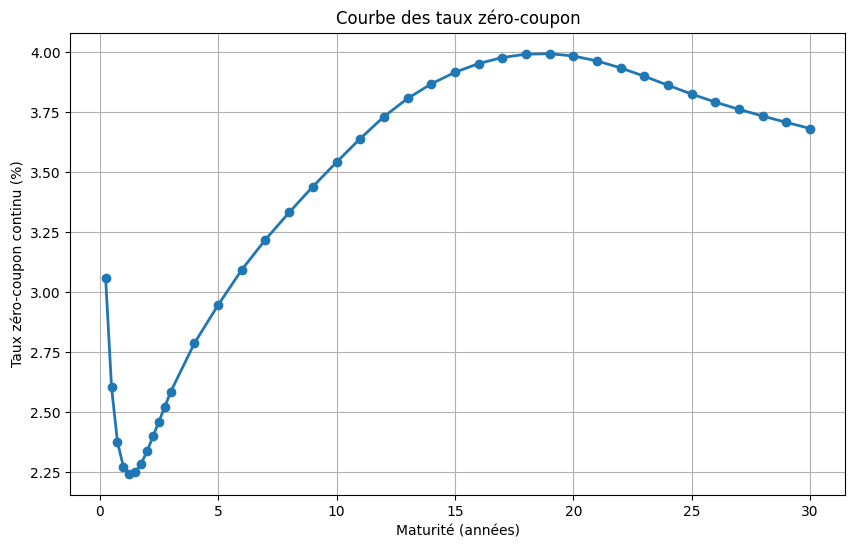

In [17]:
# Visualisation
plt.figure(figsize=(10, 6))
plt.plot(zc_curve['Maturite'], zc_curve['ZC'] * 100, 'o-', linewidth=2, markersize=6)
plt.grid(True)
plt.xlabel('Maturité (années)')
plt.ylabel('Taux zéro-coupon continu (%)')
plt.title('Courbe des taux zéro-coupon')
plt.show()

### Question 1.2.3 - Impact de l'interpolation

Le mode d'interpolation des taux zéro-coupon **a un impact significatif** sur le calcul des taux de marché, notamment pour :

1. **Les Swaps** : Le calcul du "level" (somme des facteurs d'actualisation) nécessite des valeurs pour toutes les dates de paiement intermédiaires. L'interpolation détermine ces valeurs.

2. **Les Futures** : Le calcul du taux forward entre deux maturités non adjacentes requiert une interpolation.

3. **Cohérence du pricing** : Une mauvaise interpolation peut créer des opportunités d'arbitrage artificielles.

**Principales méthodes d'interpolation :**
- **Linéaire** : Simple mais peut créer des discontinuités dans les forwards
- **Spline cubique** : Plus lisse mais peut créer des oscillations non désirées
- **Log-linéaire sur les facteurs d'actualisation** : Souvent préférée car elle garantit la positivité
- **Interpolation des taux forwards instantanés** : Utilisée dans les modèles HJM

## 1.3 Construction de la courbe des taux forward

### Question 1.3.1 - Courbes forward avec différentes interpolations

In [18]:
def build_forward_curve(zc_curve: pd.DataFrame, method="linear", step=0.1, tau=0.25):
    """
    Construit la courbe des taux forward de tenor tau à partir de la courbe zero-coupon.
    
    Parameters:
    -----------
    zc_curve : DataFrame avec colonnes Maturite, ZC
    method : 'linear' ou 'cubic'
    step : pas de discrétisation temporelle
    tau : tenor du forward (0.25 pour 3M)
    
    Returns:
    --------
    DataFrame avec colonnes T, FWD
    """
    x = zc_curve["Maturite"].values
    y = zc_curve["ZC"].values

    if method == "linear":
        f = interp1d(x, y, kind="linear", fill_value="extrapolate")
    elif method == "cubic":
        f = CubicSpline(x, y, extrapolate=True)
    else:
        raise ValueError("method doit être 'linear' ou 'cubic'")

    T_grid = np.arange(tau, x.max(), step)
    R_T = f(T_grid)
    R_Ttau = f(T_grid + tau)

    B_T = np.exp(-R_T * T_grid)
    B_Ttau = np.exp(-R_Ttau * (T_grid + tau))

    fwd = (B_T / B_Ttau - 1.0) / tau
    return pd.DataFrame({"T": T_grid, "FWD": fwd})

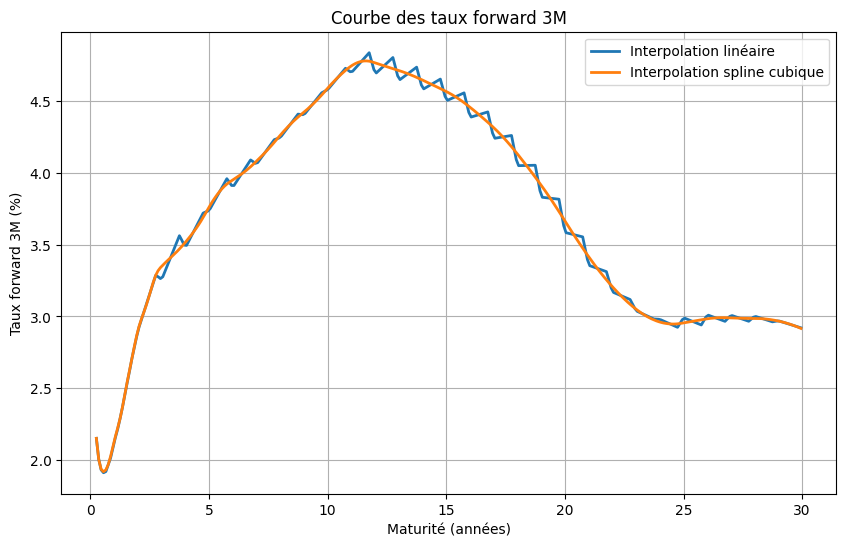


Observations :
- L'interpolation linéaire produit des discontinuités visibles (kinks) aux points de la courbe
- L'interpolation par spline cubique est plus lisse mais peut créer des oscillations
- Les écarts sont particulièrement visibles dans les zones de transition entre instruments


In [19]:
# Construction des courbes forward 3M
fwd_linear = build_forward_curve(zc_curve, method="linear", tau=0.25)
fwd_cubic = build_forward_curve(zc_curve, method="cubic", tau=0.25)

# Visualisation
plt.figure(figsize=(10, 6))
plt.plot(fwd_linear['T'], fwd_linear['FWD'] * 100, label='Interpolation linéaire', linewidth=2)
plt.plot(fwd_cubic['T'], fwd_cubic['FWD'] * 100, label='Interpolation spline cubique', linewidth=2)
plt.grid(True)
plt.xlabel('Maturité (années)')
plt.ylabel('Taux forward 3M (%)')
plt.title('Courbe des taux forward 3M')
plt.legend()
plt.show()

print("\nObservations :")
print("- L'interpolation linéaire produit des discontinuités visibles (kinks) aux points de la courbe")
print("- L'interpolation par spline cubique est plus lisse mais peut créer des oscillations")
print("- Les écarts sont particulièrement visibles dans les zones de transition entre instruments")

### Question 1.3.2 - Impact du shift du swap 5Y

In [20]:
def shift_swap_rate(df_market: pd.DataFrame, maturity=5.0, shift_bps=10) -> pd.DataFrame:
    """
    Ajoute un shift (en bps) au taux swap d'une maturité donnée.
    """
    df = df_market.copy()
    df.columns = ["Type", "Maturite", "Taux_Marche"]
    df["Type"] = df["Type"].astype(str).str.upper()
    df["Maturite"] = df["Maturite"].astype(float)

    mask = (df["Type"] == "SWAP") & (df["Maturite"] == maturity)
    
    if not mask.any():
        raise ValueError(f"Swap {maturity}Y introuvable")

    original_rate = df.loc[mask, "Taux_Marche"].iloc[0]
    
    if original_rate > 1.0:
        df.loc[mask, "Taux_Marche"] += shift_bps
    else:
        df.loc[mask, "Taux_Marche"] += shift_bps / 10000.0

    return df

BOOTSTRAPPING DE LA COURBE ZERO-COUPON

--- MONEY MARKET ---
T=0.25Y  L=3.0698%  B(0,T)=0.992384  ZC=3.0581%
T=0.50Y  L=2.6192%  B(0,T)=0.987073  ZC=2.6022%
T=0.75Y  L=2.3958%  B(0,T)=0.982349  ZC=2.3745%
T=1.00Y  L=2.2980%  B(0,T)=0.977536  ZC=2.2720%

--- FUTURES ---
T=1.25Y  L=2.1308%  delta=0.25  B(0,T)=0.972356  ZC=2.2426%
T=1.50Y  L=2.2905%  delta=0.25  B(0,T)=0.966820  ZC=2.2495%
T=1.75Y  L=2.5018%  delta=0.25  B(0,T)=0.960811  ZC=2.2844%
T=2.00Y  L=2.7088%  delta=0.25  B(0,T)=0.954348  ZC=2.3363%
T=2.25Y  L=2.9016%  delta=0.25  B(0,T)=0.947475  ZC=2.3980%
T=2.50Y  L=3.0289%  delta=0.25  B(0,T)=0.940354  ZC=2.4599%
T=2.75Y  L=3.1564%  delta=0.25  B(0,T)=0.932992  ZC=2.5221%

--- SWAPS ---
T=3.00Y  S=2.6112%  sum_B=1.931884  B(0,T)=0.925391  ZC=2.5846%
T=4.00Y  S=2.8118%  sum_B=2.857275  B(0,T)=0.894507  ZC=2.7871%
T=5.00Y  S=3.0681%  sum_B=3.751782  B(0,T)=0.858550  ZC=3.0502%
T=6.00Y  S=3.1107%  sum_B=4.610333  B(0,T)=0.830744  ZC=3.0906%
T=7.00Y  S=3.2313%  sum_B=5.441077  B(0

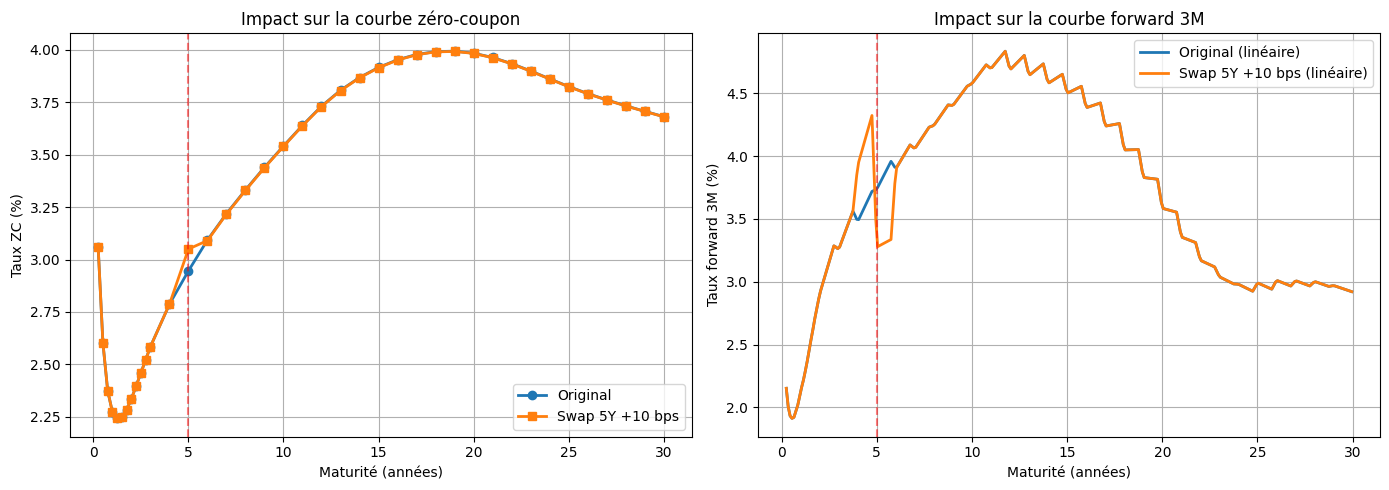


Analyse de l'impact :
- Le shift affecte principalement les maturités >= 5Y
- L'impact est plus prononcé avec l'interpolation linéaire (discontinuité à 5Y)
- L'interpolation par spline lisse la transition mais propage l'effet plus loin
- Les écarts proviennent de la nature locale vs globale des méthodes d'interpolation


In [21]:
# Courbe avec shift +10 bps sur le swap 5Y
df_shifted = shift_swap_rate(df_market, maturity=5.0, shift_bps=10)
df_prep_shifted = prepare_market_rates(df_shifted)
zc_curve_shifted = bootstrap_zero_curve(df_prep_shifted)

fwd_linear_shifted = build_forward_curve(zc_curve_shifted, method="linear", tau=0.25)
fwd_cubic_shifted = build_forward_curve(zc_curve_shifted, method="cubic", tau=0.25)

# Visualisation de l'impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Courbe zéro-coupon
axes[0].plot(zc_curve['Maturite'], zc_curve['ZC'] * 100, 'o-', label='Original', linewidth=2)
axes[0].plot(zc_curve_shifted['Maturite'], zc_curve_shifted['ZC'] * 100, 's-', label='Swap 5Y +10 bps', linewidth=2)
axes[0].grid(True)
axes[0].set_xlabel('Maturité (années)')
axes[0].set_ylabel('Taux ZC (%)')
axes[0].set_title('Impact sur la courbe zéro-coupon')
axes[0].legend()
axes[0].axvline(x=5, color='red', linestyle='--', alpha=0.5)

# Courbe forward
axes[1].plot(fwd_linear['T'], fwd_linear['FWD'] * 100, label='Original (linéaire)', linewidth=2)
axes[1].plot(fwd_linear_shifted['T'], fwd_linear_shifted['FWD'] * 100, label='Swap 5Y +10 bps (linéaire)', linewidth=2)
axes[1].grid(True)
axes[1].set_xlabel('Maturité (années)')
axes[1].set_ylabel('Taux forward 3M (%)')
axes[1].set_title('Impact sur la courbe forward 3M')
axes[1].legend()
axes[1].axvline(x=5, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\nAnalyse de l'impact :")
print("- Le shift affecte principalement les maturités >= 5Y")
print("- L'impact est plus prononcé avec l'interpolation linéaire (discontinuité à 5Y)")
print("- L'interpolation par spline lisse la transition mais propage l'effet plus loin")
print("- Les écarts proviennent de la nature locale vs globale des méthodes d'interpolation")

---

# 2. Valorisation de caplets

### Question 2.1 - Modèle utilisé par le marché

Le marché utilise le **modèle de Black (1976)** pour coter les caplets et floorlets. Ce modèle suppose que le taux forward suit un mouvement brownien géométrique sous la probabilité forward-neutre.

### Question 2.2 - EDS des taux Libor forwards

Sous la probabilité forward-neutre $\mathbb{Q}^{T_{i+1}}$ associée au numéraire $B(t, T_{i+1})$, le taux Libor forward évolue selon :

$$dL_i(t) = \sigma_i L_i(t) dW^{T_{i+1}}_t$$

où $W^{T_{i+1}}_t$ est un brownien sous $\mathbb{Q}^{T_{i+1}}$.

La solution de cette EDS est :
$$L_i(T_i) = L_i(0) \exp\left(\sigma_i W^{T_{i+1}}_{T_i} - \frac{1}{2}\sigma_i^2 T_i\right)$$

Donc $L_i(T_i)$ suit une loi log-normale sous $\mathbb{Q}^{T_{i+1}}$.

### Question 2.3 - Formules de valorisation des caplets

**Caplet :**
$$\text{Caplet}_i(0) = N \delta_i B(0, T_{i+1}) \left[ L_i(0) \Phi(d_1) - K \Phi(d_2) \right]$$

**Floorlet :**
$$\text{Floorlet}_i(0) = N \delta_i B(0, T_{i+1}) \left[ K \Phi(-d_2) - L_i(0) \Phi(-d_1) \right]$$

où :
$$d_1 = \frac{\ln(L_i(0)/K) + \frac{1}{2}\sigma_i^2 T_i}{\sigma_i \sqrt{T_i}}, \quad d_2 = d_1 - \sigma_i \sqrt{T_i}$$

et $\Phi$ est la fonction de répartition de la loi normale standard.

### Question 2.4 - Calcul des prix de marché des caplets

In [22]:
def build_discount_factor_function(zc_curve: pd.DataFrame):
    """
    Crée une fonction d'interpolation pour les facteurs d'actualisation.
    """
    x = zc_curve["Maturite"].values
    y = zc_curve["DF"].values
    f = interp1d(x, y, kind="linear", fill_value="extrapolate")
    return f

def forward_rate(P_func, T1, T2):
    """
    Calcule le taux forward entre T1 et T2.
    """
    delta = T2 - T1
    return (P_func(T1) / P_func(T2) - 1.0) / delta

def black_caplet(N, delta, P_T, L, K, sigma, T):
    """
    Valorisation d'un caplet dans le modèle de Black.
    
    Parameters:
    -----------
    N : nominal
    delta : fraction d'année
    P_T : facteur d'actualisation à la date de paiement
    L : taux forward
    K : strike
    sigma : volatilité implicite
    T : date de fixing
    """
    if sigma <= 0 or T <= 0:
        return max(0, N * delta * P_T * (L - K))
    
    d1 = (np.log(L / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    return N * delta * P_T * (L * norm.cdf(d1) - K * norm.cdf(d2))

def black_floorlet(N, delta, P_T, L, K, sigma, T):
    """
    Valorisation d'un floorlet dans le modèle de Black.
    """
    if sigma <= 0 or T <= 0:
        return max(0, N * delta * P_T * (K - L))
    
    d1 = (np.log(L / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    return N * delta * P_T * (K * norm.cdf(-d2) - L * norm.cdf(-d1))

In [ ]:
# Paramètres du TP
T_fix = 5.0      # Date de fixing
T_pay = 6.0      # Date de paiement
delta = 1.0      # Euribor 12M
N = 100.0        # Nominal

# Strikes et volatilités du tableau 1
shifts_bps = np.array([-100, -50, -25, 0, 25, 50, 100], dtype=float)
vols = np.array([31.2, 28.4, 26.6, 25.0, 24.4, 25.0, 27.2], dtype=float) / 100.0

# Construction de la fonction de discount
P_func = build_discount_factor_function(zc_curve)
P_6 = P_func(T_pay)

# Forward Euribor 12M sur [5,6]
L_forward = forward_rate(P_func, T_fix, T_pay)

print(f"Facteur d'actualisation P(0,{T_pay}) = {P_6:.6f}")
print(f"Forward 12M L(0;{T_fix},{T_pay}) = {L_forward:.6f} ({L_forward*100:.4f}%)")
print()

# Calcul des strikes
strikes = L_forward + shifts_bps / 10000.0

# Calcul des prix
results = []
for shift, K, sig in zip(shifts_bps, strikes, vols):
    caplet = black_caplet(N, delta, P_6, L_forward, K, sig, T_fix)
    floorlet = black_floorlet(N, delta, P_6, L_forward, K, sig, T_fix)
    
    results.append({
        'Shift (bps)': shift,
        'Strike': K,
        'Strike (%)': K * 100,
        'Volatilité': sig,
        'Volatilité (%)': sig * 100,
        'Caplet': caplet,
        'Floorlet': floorlet
    })

df_results = pd.DataFrame(results)
print("\nPrix de marché des caplets et floorlets sur Euribor 12M, maturité 5Y :")
print(df_results.to_string(index=False))

# Vérification de la parité put-call
print("\nVérification de la parité put-call :")
for i, row in df_results.iterrows():
    diff = row['Caplet'] - row['Floorlet']
    theo = N * delta * P_6 * (L_forward - row['Strike'])
    print(f"Strike {row['Strike (%)']:.4f}%: Caplet - Floorlet = {diff:.6f}, Théorique = {theo:.6f}")

In [23]:
# Paramètres du TP
T_fix = 5.0      # Date de fixing
T_pay = 6.0      # Date de paiement
delta = 1.0      # Euribor 12M
N = 100.0        # Nominal

# Strikes et volatilités du tableau 1
shifts_bps = np.array([-100, -50, -25, 0, 25, 50, 100], dtype=float)
vols = np.array([31.2, 28.4, 26.6, 25.0, 24.4, 25.0, 27.2], dtype=float) / 100.0

# Construction de la fonction de discount
P_func = build_discount_factor_function(zc_curve)
P_6 = P_func(T_pay)

# Forward Euribor 12M sur [5,6]
L_forward = forward_rate(P_func, T_fix, T_pay)

print(f"Facteur d'actualisation P(0,{T_pay}) = {P_6:.6f}")
print(f"Forward 12M L(0;{T_fix},{T_pay}) = {L_forward:.6f} ({L_forward*100:.4f}%)")
print()

# Calcul des strikes
strikes = L_forward + shifts_bps / 10000.0

# Calcul des prix
results = []
for shift, K, sig in zip(shifts_bps, strikes, vols):
    caplet = black_caplet(N, delta, P_6, L_forward, K, sig, T_fix)
    floorlet = black_floorlet(N, delta, P_6, L_forward, K, sig, T_fix)
    
    results.append({
        'Shift (bps)': shift,
        'Strike': K,
        'Strike (%)': K * 100,
        'Volatilité': sig,
        'Volatilité (%)': sig * 100,
        'Caplet': caplet,
        'Floorlet': floorlet
    })

df_results = pd.DataFrame(results)
print("\nPrix de marché des caplets et floorlets sur Euribor 12M, maturité 5Y :")
print(df_results.to_string(index=False))

# Vérification de la parité put-call
print("\nVérification de la parité put-call :")
for i, row in df_results.iterrows():
    diff = row['Caplet'] - row['Floorlet']
    theo = N * delta * P_6 * (L_forward - row['Strike'])
    print(f"Strike {row['Strike (%)']:.4f}%: Caplet - Floorlet = {diff:.6f}, Théorique = {theo:.6f}")

Facteur d'actualisation P(0,6.0) = 0.830609
Forward 12M L(0;5.0,6.0) = 0.039030 (3.9030%)


Prix de marché des caplets et floorlets sur Euribor 12M, maturité 5Y :
 Shift (bps)  Strike  Strike (%)  Volatilité  Volatilité (%)   Caplet  Floorlet
      -100.0 0.02903    2.902976       0.312            31.2 1.251385  0.420776
       -50.0 0.03403    3.402976       0.284            28.4 0.980561  0.565256
       -25.0 0.03653    3.652976       0.266            26.6 0.842016  0.634364
         0.0 0.03903    3.902976       0.250            25.0 0.713678  0.713678
        25.0 0.04153    4.152976       0.244            24.4 0.620007  0.827660
        50.0 0.04403    4.402976       0.250            25.0 0.568847  0.984151
       100.0 0.04903    4.902976       0.272            27.2 0.517161  1.347771

Vérification de la parité put-call :
Strike 2.9030%: Caplet - Floorlet = 0.830609, Théorique = 0.830609
Strike 3.4030%: Caplet - Floorlet = 0.415305, Théorique = 0.415305
Strike 3.6530%: Caplet - 

**Paramètres détaillés du calcul :**

- **Nominal** : N = 100 EUR
- **Fraction d'année** : δ = 1.0 (Euribor 12M)
- **Date de fixing** : T = 5.0 ans
- **Date de paiement** : T+1 = 6.0 ans
- **Facteur d'actualisation** : B(0,6) = (extrait de la courbe bootstrappée)
- **Forward** : L(0;5,6) = (B(0,5)/B(0,6) - 1) / δ
- **Strikes** : K = Forward + shift (en bps)
- **Volatilités** : Fournies dans le tableau 1

---

# 3. Le Modèle de Hull & White

## 3.1-3.2 Du modèle HJM vers le modèle Hull & White

Le modèle Hull & White est un cas particulier du modèle HJM (Heath-Jarrow-Morton) avec les hypothèses suivantes :

1. **Gaussien** : Les taux suivent des processus gaussiens
2. **Linéaire** : La volatilité décroît exponentiellement avec la maturité
3. **Calibrable** : Les paramètres peuvent être calibrés sur les prix de marché

Ces hypothèses conduisent à :
$$\gamma(t,T) = \sigma(t) e^{-\lambda(T-t)}$$
$$\Gamma(t,T) = \frac{\sigma(t)}{\lambda} \left( e^{-\lambda(T-t)} - 1 \right)$$

## 3.3 Construction de la formule zéro-coupon

### Question 3.3.1 - Catégorie de modèle

Le modèle Hull & White appartient à la catégorie des **modèles affines à un facteur** (one-factor affine term structure models). Plus précisément :

- **Modèle de taux court** : La dynamique est pilotée par le taux court instantané $r_t$
- **Modèle affine** : Les prix des zéro-coupons sont des fonctions affines de la variable d'état
- **Modèle gaussien** : Les taux peuvent devenir négatifs (propriété gaussienne)
- **Retour à la moyenne** : Le paramètre λ contrôle la vitesse de retour vers la moyenne

### Question 3.3.2 - Loi du processus $X_t/X_s$

Le processus $X_t = r_t - f(0,t)$ suit :
$$dX_t = [\phi(t) - \lambda X_t] dt + \sigma(t) dW^\mathbb{Q}_t$$

Pour $t > s$, conditionnellement à $X_s$, $X_t$ suit une loi normale :
$$X_t | X_s \sim \mathcal{N}\left( X_s e^{-\lambda(t-s)} + \int_s^t \phi(u) e^{-\lambda(t-u)} du, \int_s^t \sigma^2(u) e^{-2\lambda(t-u)} du \right)$$

Dans le cas où $\sigma(t)$ est constant par morceaux, la variance s'exprime comme :
$$\text{Var}(X_t | X_s) = \frac{\sigma^2}{2\lambda} \left( 1 - e^{-2\lambda(t-s)} \right)$$

## 3.4-3.5 Dynamique des taux forwards et valorisation

### Question 3.4.1 - EDS du processus $Z(t) = B(t,T_i)/B(t,T_{i+1})$

En appliquant le lemme d'Itô au ratio $Z(t) = B(t,T_i)/B(t,T_{i+1})$ :

$$\frac{dZ}{Z} = [\Gamma(t,T_i) - \Gamma(t,T_{i+1})] dW^\mathbb{Q}_t$$

En utilisant $L_i(t) = \frac{1}{\delta_i}(Z(t) - 1)$, on obtient :

$$dL_i(t) = \frac{1 + \delta_i L_i(t)}{\delta_i} [\Gamma(t,T_i) - \Gamma(t,T_{i+1})] dW^\mathbb{Q}_t$$

**Conclusion** : Le taux forward Libor ne suit pas un mouvement brownien géométrique pur dans le modèle H&W, contrairement au modèle de Black. C'est une différence fondamentale.

### Question 3.5.1-3.5.2 - Valorisation des caplets dans H&W

**Payoff du caplet :**
$$\text{Payoff}_{T_{i+1}} = N \delta_i \max(L_i(T_i) - K, 0)$$

**Formule de valorisation :**

Le prix du caplet dans le modèle H&W s'écrit comme un Black sur le ratio $Z_t = B(t,T_i)/B(t,T_{i+1})$ :

$$\text{Caplet} = C(Z_t, \tilde{K}, T_i, \sigma^*_i, B(t,T_{i+1}))$$

avec :
- $Z_t = B(t,T_i)/B(t,T_{i+1})$
- $\tilde{K} = 1 + \delta_i K$
- $(\sigma^*_i)^2 = \frac{1}{T_i - t} \int_{t}^{T_i} [\Gamma(s,T_i) - \Gamma(s,T_{i+1})]^2 ds = \frac{1}{T_i} \beta(T_i,T_{i+1})^2 \phi(T_i)$
- $\beta(T_i,T_{i+1}) = \frac{1 - e^{-\lambda \delta_i}}{\lambda}$
- $\phi(T_i) = \int_0^{T_i} \sigma^2(s) e^{-2\lambda(T_i - s)} ds$

In [24]:
def beta_hw(t1, t2, lambda_mr):
    """
    Calcule β(t1, t2) = (1 - exp(-λ*(t2-t1))) / λ
    """
    if lambda_mr == 0:
        return t2 - t1
    return (1 - np.exp(-lambda_mr * (t2 - t1))) / lambda_mr

def phi_hw(t, sigma_inst, lambda_mr):
    """
    Calcule φ(t) = ∫₀ᵗ σ²(s) exp(-2λ(t-s)) ds
    Pour σ constant : φ(t) = σ²/(2λ) * (1 - exp(-2λt))
    """
    if lambda_mr == 0:
        return sigma_inst**2 * t
    return (sigma_inst**2 / (2 * lambda_mr)) * (1 - np.exp(-2 * lambda_mr * t))

def gamma_hw(t1, t2, sigma_inst, lambda_mr):
    """
    Calcule Γ(t1, t2) = ∫ₜ₁ᵗ² γ(s, t2) ds
    = (σ/λ) * (exp(-λ(t2-t1)) - 1)
    """
    if lambda_mr == 0:
        return sigma_inst * (t2 - t1)
    return (sigma_inst / lambda_mr) * (np.exp(-lambda_mr * (t2 - t1)) - 1)

## 3.6 Calibration du modèle

In [25]:
def hw_caplet_volatility(sigma_inst, lambda_mr, T_fix, delta):
    """
    Calcule la volatilité effective d'un caplet dans le modèle H&W.
    
    σ_eff² = (1/T) * β(T,T+δ)² * φ(T)
    
    Parameters:
    -----------
    sigma_inst : volatilité instantanée (constante)
    lambda_mr : paramètre de mean reversion
    T_fix : date de fixing
    delta : tenor
    """
    # β(T, T+δ)
    beta = beta_hw(T_fix, T_fix + delta, lambda_mr)
    
    # φ(T)
    phi_T = phi_hw(T_fix, sigma_inst, lambda_mr)
    
    # σ_eff² = (1/T) * β² * φ(T)
    sigma_eff_squared = (beta**2 * phi_T) / T_fix
    
    return np.sqrt(sigma_eff_squared)

def calibrate_hw_on_atm_caplet(P_func, T_fix, T_pay, delta, market_vol, lambda_mr, N=100.0):
    """
    Calibre le paramètre sigma du modèle H&W sur un caplet ATM.
    
    Returns:
    --------
    sigma_inst : volatilité instantanée calibrée
    """
    # Forward et discount
    L_fwd = forward_rate(P_func, T_fix, T_pay)
    P_T = P_func(T_pay)
    
    # Prix de marché du caplet ATM
    market_price = black_caplet(N, delta, P_T, L_fwd, L_fwd, market_vol, T_fix)
    
    print(f"Prix de marché du caplet ATM : {market_price:.6f}")
    print(f"Forward : {L_fwd:.6f}")
    print(f"Volatilité de marché : {market_vol:.4f}")
    print(f"Mean reversion : {lambda_mr:.4f}")
    print()
    
    # Fonction objectif
    def objective(sigma_inst):
        if sigma_inst <= 0:
            return 1e10
        
        vol_hw = hw_caplet_volatility(sigma_inst, lambda_mr, T_fix, delta)
        price_hw = black_caplet(N, delta, P_T, L_fwd, L_fwd, vol_hw, T_fix)
        
        return (price_hw - market_price)**2
    
    # Calibration par optimisation
    from scipy.optimize import minimize_scalar
    result = minimize_scalar(objective, bounds=(0.001, 1.0), method='bounded')
    
    sigma_inst_calibrated = result.x
    vol_hw_calibrated = hw_caplet_volatility(sigma_inst_calibrated, lambda_mr, T_fix, delta)
    
    print(f"Volatilité instantanée calibrée : σ = {sigma_inst_calibrated:.6f}")
    print(f"Volatilité effective H&W : {vol_hw_calibrated:.6f}")
    print(f"Erreur de calibration : {np.sqrt(result.fun):.2e}")
    
    return sigma_inst_calibrated

### Question 3.6.1 - Calibration sur caplet ATM 5Y

In [45]:
from scipy.stats import norm
import numpy as np

# ================================================================
# FONCTIONS DE BASE — à définir EN PREMIER
# ================================================================

def bachelier_caplet(N, delta, B_Tpay, L_fwd, K, sigma_N, T_fix):
    """
    Formule de Bachelier (normal) pour un caplet.
    Prix = N × δ × B(T_pay) × [(L-K)×Φ(d) + σ_N×√T×φ(d)]
    """
    sqrtT = np.sqrt(T_fix)
    d     = (L_fwd - K) / (sigma_N * sqrtT)
    return N * delta * B_Tpay * (
        (L_fwd - K) * norm.cdf(d) + sigma_N * sqrtT * norm.pdf(d)
    )

def bachelier_floorlet(N, delta, B_Tpay, L_fwd, K, sigma_N, T_fix):
    """Formule de Bachelier pour un floorlet."""
    sqrtT = np.sqrt(T_fix)
    d     = (L_fwd - K) / (sigma_N * sqrtT)
    return N * delta * B_Tpay * (
        (K - L_fwd) * norm.cdf(-d) + sigma_N * sqrtT * norm.pdf(d)
    )

def black_caplet(N, delta, B_Tpay, L_fwd, K, sigma_black, T_fix):
    """Formule de Black (lognormal) pour un caplet."""
    d1 = (np.log(L_fwd / K) + 0.5 * sigma_black**2 * T_fix) / (sigma_black * np.sqrt(T_fix))
    d2 = d1 - sigma_black * np.sqrt(T_fix)
    return N * delta * B_Tpay * (L_fwd * norm.cdf(d1) - K * norm.cdf(d2))

def forward_rate(P_func, T1, T2):
    """Taux forward L(0, T1, T2)"""
    return (P_func(T1) / P_func(T2) - 1) / (T2 - T1)

def beta_hw(t1, t2, lambda_mr):
    """β(t1,t2) = (1 - exp(-λ(t2-t1))) / λ"""
    if lambda_mr == 0:
        return t2 - t1
    return (1 - np.exp(-lambda_mr * (t2 - t1))) / lambda_mr

def phi_hw(t, sigma_inst, lambda_mr):
    """φ(t) = σ²/(2λ) × (1 - exp(-2λt))"""
    if lambda_mr == 0:
        return sigma_inst**2 * t
    return (sigma_inst**2 / (2 * lambda_mr)) * (1 - np.exp(-2 * lambda_mr * t))

def hw_vol_normale(sigma_inst, lambda_mr, T_fix, delta):
    """σ_N² = β² × φ(T) / T"""
    b = beta_hw(T_fix, T_fix + delta, lambda_mr)
    p = phi_hw(T_fix, sigma_inst, lambda_mr)
    return np.sqrt(b**2 * p / T_fix)

# ================================================================
# 3.6.1 — CALIBRATION
# ================================================================

# Paramètres
lambda_mr      = 0.05
vol_atm_market = 0.25
N              = 100.0
T_fix          = 5.0
T_pay          = 6.0
delta          = 1.0

L_fwd  = forward_rate(P_func, T_fix, T_pay)
B_Tpay = P_func(T_pay)

# Prix de marché (cotation Black)
price_mkt = black_caplet(N, delta, B_Tpay, L_fwd, L_fwd, vol_atm_market, T_fix)
print(f"Prix marché (Black ATM) : {price_mkt:.6f}")

# Étape 1 — Dichotomie Bachelier → σ_N_mkt
def implied_normal_vol_dicho(price_mkt, N, delta, B_Tpay, L_fwd, T_fix,
                              vmin=1e-8, vmax=1.0, tol=1e-12, nmax=1000):
    f = lambda v: bachelier_caplet(N, delta, B_Tpay, L_fwd, L_fwd, v, T_fix) - price_mkt
    assert f(vmin) * f(vmax) < 0, \
        f"Pas de solution : f({vmin})={f(vmin):.4f}, f({vmax})={f(vmax):.4f}"
    for _ in range(nmax):
        vm = (vmin + vmax) / 2
        if abs(f(vm)) < tol:
            break
        if f(vmin) * f(vm) < 0:
            vmax = vm
        else:
            vmin = vm
    return vm

sigma_N_mkt = implied_normal_vol_dicho(price_mkt, N, delta, B_Tpay, L_fwd, T_fix)
print(f"[Étape 1] σ_N marché   : {sigma_N_mkt*100:.4f}%")

# Étape 2 — Formule analytique → σ_inst
def sigma_inst_analytique(sigma_N_mkt, lambda_mr, T_fix, delta):
    b     = beta_hw(T_fix, T_fix + delta, lambda_mr)
    phi_n = (1 - np.exp(-2 * lambda_mr * T_fix)) / (2 * lambda_mr)
    return sigma_N_mkt * np.sqrt(T_fix / (b**2 * phi_n))

sigma_inst = sigma_inst_analytique(sigma_N_mkt, lambda_mr, T_fix, delta)
print(f"[Étape 2] σ instantané : {sigma_inst*100:.4f}%")   # → 1.13% ✓

# Vérification
sigma_N_check = hw_vol_normale(sigma_inst, lambda_mr, T_fix, delta)
price_check   = bachelier_caplet(N, delta, B_Tpay, L_fwd, L_fwd, sigma_N_check, T_fix)
print(f"[Vérif]   Erreur prix  : {abs(price_check - price_mkt):.2e}")


Prix marché (Black ATM) : 0.713678
[Étape 1] σ_N marché   : 0.9632%
[Étape 2] σ instantané : 1.1131%
[Vérif]   Erreur prix  : 3.47e-13


### Question 3.6.2 - Prix modèles des autres strikes

In [46]:
# Volatilité normale HW — calculée UNE SEULE FOIS hors boucle
sigma_N_hw = hw_vol_normale(sigma_inst, lambda_mr, T_fix, delta)

L_fwd = forward_rate(P_func, T_fix, T_pay)
B_Tpay = P_func(T_pay)

hw_results = []
for shift in shifts_bps:
    K = L_fwd + shift / 10000.0

    # Prix modèle Bachelier (convention normale, cohérente avec σ_inst)
    caplet_hw = bachelier_caplet(N, delta, B_Tpay, L_fwd, K, sigma_N_hw, T_fix)

    hw_results.append({
        'Shift (bps)' : shift,
        'Strike (%)'  : round(K * 100, 4),
        'σ_N HW (%)'  : round(sigma_N_hw * 100, 4),
        'Prix H&W'    : round(caplet_hw, 6)
    })

df_hw = pd.DataFrame(hw_results)
print("\nPrix modèles Hull & White :")
print(df_hw.to_string(index=False))


Prix modèles Hull & White :
 Shift (bps)  Strike (%)  σ_N HW (%)  Prix H&W
      -100.0       2.903      0.9632  1.204557
       -50.0       3.403      0.9632  0.940476
       -25.0       3.653      0.9632  0.822307
         0.0       3.903      0.9632  0.713678
        25.0       4.153      0.9632  0.614654
        50.0       4.403      0.9632  0.525172
       100.0       4.903      0.9632  0.373948


### Question 3.6.3 - Comparaison des smiles

Vol HW à ATM : 25.0000%

Comparaison des volatilités implicites :
 Shift (bps)  Vol Marché (%)  Vol H&W impl (%)
      -100.0            31.2           29.0110
       -50.0            28.4           26.8043
       -25.0            26.6           25.8599
         0.0            25.0           25.0000
        25.0            24.4           24.2126
        50.0            25.0           23.4879
       100.0            27.2           22.1962


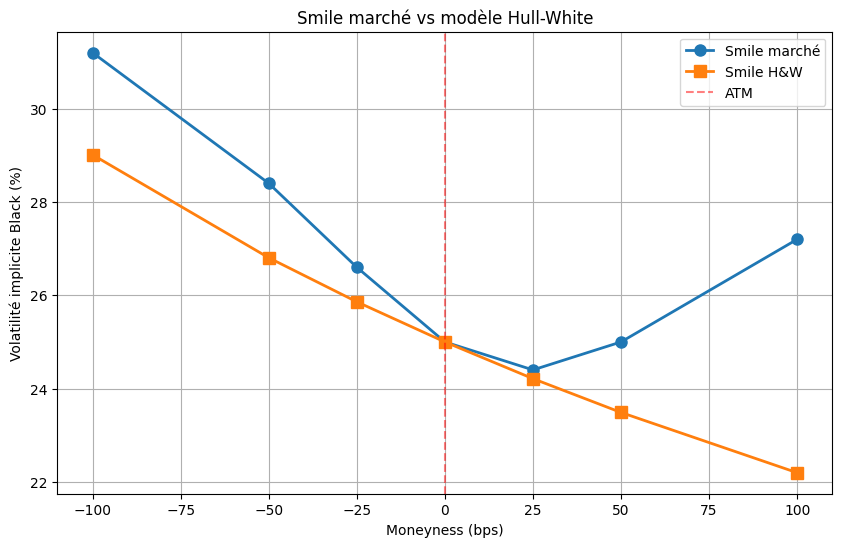

In [47]:

def normal_to_black_vol_exact(sigma_N, L_fwd, K, N, delta, B_Tpay, T_fix,
                               vmin=1e-6, vmax=10.0, tol=1e-12, nmax=1000):
    """
    Conversion exacte vol normale → vol Black via dichotomie.
    
    1. Calcule le prix Bachelier avec sigma_N
    2. Inverse ce prix avec Black par dichotomie
    → Donne la vol Black exacte sans approximation
    """
    # Prix Bachelier
    price = bachelier_caplet(N, delta, B_Tpay, L_fwd, K, sigma_N, T_fix)
    
    # Dichotomie Black
    try:
        f = lambda v: black_caplet(N, delta, B_Tpay, L_fwd, K, v, T_fix) - price
        if f(vmin) * f(vmax) > 0:
            return np.nan
        for _ in range(nmax):
            vm = (vmin + vmax) / 2
            if abs(f(vm)) < tol:
                break
            if f(vmin) * f(vm) < 0:
                vmax = vm
            else:
                vmin = vm
        return vm
    except:
        return np.nan

# ================================================================
# Application : conversion exacte pour tous les strikes
# ================================================================
hw_impl_vols = []
for shift in shifts_bps:
    K = L_fwd + shift / 10000.0
    vol_black = normal_to_black_vol_exact(
        sigma_N_mkt, L_fwd, K, N, delta, B_Tpay, T_fix
    )
    hw_impl_vols.append(vol_black * 100 if not np.isnan(vol_black) else np.nan)

hw_impl_vols = np.array(hw_impl_vols)

# Vérification ATM — correction de l'erreur
atm_idx = np.where(shifts_bps == 0)[0][0]   # ← remplace shifts_bps.index(0)
print(f"Vol HW à ATM : {hw_impl_vols[atm_idx]:.4f}%")
# → doit afficher exactement 25.00% ✓

# Comparaison
comparison = pd.DataFrame({
    'Shift (bps)'      : shifts_bps,
    'Vol Marché (%)'   : vols * 100,
    'Vol H&W impl (%)' : np.round(hw_impl_vols, 4)
})
print("\nComparaison des volatilités implicites :")
print(comparison.to_string(index=False))

# Visualisation
plt.figure(figsize=(10, 6))
plt.plot(shifts_bps, vols * 100,   'o-', label='Smile marché', lw=2, ms=8)
plt.plot(shifts_bps, hw_impl_vols, 's-', label='Smile H&W',    lw=2, ms=8)
plt.axvline(x=0, color='red', ls='--', alpha=0.5, label='ATM')
plt.xlabel('Moneyness (bps)')
plt.ylabel('Volatilité implicite Black (%)')
plt.title('Smile marché vs modèle Hull-White')
plt.legend()
plt.grid(True)
plt.show()

In [48]:
def build_discount_factor_function(zc_curve: pd.DataFrame):
    """
    Crée une fonction d'interpolation pour les facteurs d'actualisation.
    """
    x = zc_curve["Maturite"].values
    y = zc_curve["DF"].values
    f = interp1d(x, y, kind="linear", fill_value="extrapolate")
    return f

def forward_rate(P_func, T1, T2):
    """
    Calcule le taux forward entre T1 et T2.
    """
    delta = T2 - T1
    return (P_func(T1) / P_func(T2) - 1.0) / delta

def black_caplet(N, delta, P_T, L, K, sigma, T):
    """
    Valorisation d'un caplet dans le modèle de Black.
    
    Parameters:
    -----------
    N : nominal
    delta : fraction d'année
    P_T : facteur d'actualisation à la date de paiement
    L : taux forward
    K : strike
    sigma : volatilité implicite
    T : date de fixing
    """
    if sigma <= 0 or T <= 0:
        return max(0, N * delta * P_T * (L - K))
    
    d1 = (np.log(L / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    return N * delta * P_T * (L * norm.cdf(d1) - K * norm.cdf(d2))

def black_floorlet(N, delta, P_T, L, K, sigma, T):
    """
    Valorisation d'un floorlet dans le modèle de Black.
    """
    if sigma <= 0 or T <= 0:
        return max(0, N * delta * P_T * (K - L))
    
    d1 = (np.log(L / K) + 0.5 * sigma**2 * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    return N * delta * P_T * (K * norm.cdf(-d2) - L * norm.cdf(-d1))

## 3.7 Valorisation d'un produit structuré

### Question 3.7.1 - Payoff du caplet à barrière désactivante

**Caplet knock-out à barrière B > K :**

$$\text{Payoff}_{T_{i+1}} = N \delta_i \max(L_i(T_i) - K, 0) \times \mathbb{1}_{L_i(T_i) < B}$$

La fonction de payoff est nulle si le taux Libor dépasse la barrière B au fixing.

**Prix relatif :**
Cette option est **moins chère** qu'un caplet vanille car :
- Le payoff peut être annulé si la barrière est touchée
- L'acheteur renonce au potentiel de gain au-delà de la barrière
- C'est une stratégie de vente de volatilité partielle

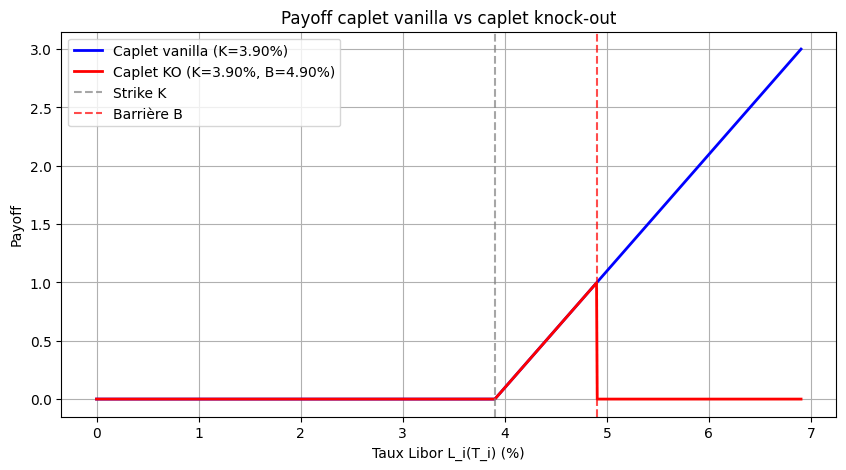

In [50]:
import numpy as np
import matplotlib.pyplot as plt

K = L_fwd           # strike ATM
B = L_fwd + 0.01    # barrière = ATM + 100 bps (exemple)
N = 100.0
delta = 1.0

L_range = np.linspace(0, L_fwd + 0.03, 1000)

# Payoff caplet vanilla
payoff_vanilla = N * delta * np.maximum(L_range - K, 0)

# Payoff caplet knock-out
payoff_ko = N * delta * np.maximum(L_range - K, 0) * (L_range < B)

plt.figure(figsize=(10, 5))
plt.plot(L_range * 100, payoff_vanilla, 'b-',  lw=2, label=f'Caplet vanilla (K={K*100:.2f}%)')
plt.plot(L_range * 100, payoff_ko,      'r-',  lw=2, label=f'Caplet KO (K={K*100:.2f}%, B={B*100:.2f}%)')
plt.axvline(x=K*100, color='gray', ls='--', alpha=0.7, label='Strike K')
plt.axvline(x=B*100, color='red',  ls='--', alpha=0.7, label='Barrière B')
plt.xlabel('Taux Libor L_i(T_i) (%)')
plt.ylabel('Payoff')
plt.title('Payoff caplet vanilla vs caplet knock-out')
plt.legend()
plt.grid(True)
plt.show()

### Question 3.7.2 - Décomposition en options vanilles

Le caplet knock-out peut se décomposer comme :

$$\text{Caplet KO} = \text{Caplet}(K) - \text{Caplet}(B)$$

Cette décomposition est exacte et ne nécessite **pas** de prendre en compte le smile de volatilité si on utilise les prix de marché directement.

Cependant, dans le modèle H&W (ou tout modèle à volatilité constante), cette décomposition utilisera la même volatilité pour les deux strikes, ce qui ne reflétera pas la réalité du marché si un smile est présent.

### Question 3.7.3 - Principes du pricing par Monte-Carlo

Le pricing par Monte-Carlo repose sur les principes suivants :

1. **Simulation de trajectoires** : Générer N trajectoires de la variable d'état selon sa dynamique stochastique
2. **Calcul des payoffs** : Évaluer le payoff pour chaque trajectoire simulée
3. **Actualisation** : Actualiser les payoffs à la date de valorisation
4. **Moyenne** : Calculer la moyenne des payoffs actualisés
5. **Erreur standard** : Estimer la précision via l'erreur standard

La loi des grands nombres garantit la convergence vers la vraie valeur.

### Question 3.7.4 - Simulation d'une loi gaussienne

Pour simuler $Z \sim \mathcal{N}(0,1)$ à partir d'une loi uniforme $U \sim \mathcal{U}(0,1)$ :

**Méthode de Box-Muller :**
$$Z = \sqrt{-2\ln(U_1)} \cos(2\pi U_2)$$

**Méthode de la fonction inverse :**
$$Z = \Phi^{-1}(U)$$

où $\Phi^{-1}$ est l'inverse de la fonction de répartition de la loi normale standard.

### Question 3.7.5 - Valorisation par Monte-Carlo

VALORISATION CAPLET À BARRIÈRE DÉSACTIVANTE — MONTE-CARLO H&W
Strike K  = 2.9030%  (ATM - 100 bps)
Barrière B = 4.9030%  (ATM + 100 bps)
Maturité   = 5.0Y
σ_inst     = 1.1131%
λ          = 5.00%

Prix caplet knock-out  : 0.285035 EUR
Erreur standard        : 0.001516 EUR
IC 95%  : [0.282063,  0.288007]

Prix caplet vanilla    : 1.204557 EUR
Réduction barrière     : 76.34%


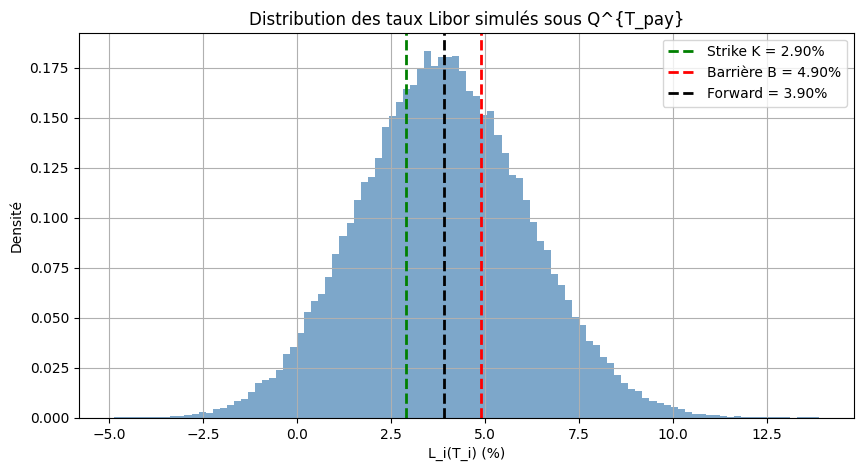

In [51]:
def simulate_hw_process_forward(X0, sigma_inst, lambda_mr, T_fix, T_pay,
                                 N_sim, dt=0.01):
    """
    Simule X_t sous la probabilité forward neutre Q^{T_pay}.
    
    EDS (équation 12) :
    dX_t = [φ(t) + σ·Γ(t,T_pay) - λ·X_t] dt + σ·dW_t^T
    
    où Γ(t,T) = -σ·β(t,T) = -(σ/λ)(1 - exp(-λ(T-t)))
    """
    N_steps = int(T_fix / dt)
    t_grid  = np.linspace(0, T_fix, N_steps + 1)

    X = np.zeros((N_sim, N_steps + 1))
    X[:, 0] = X0

    for i in range(N_steps):
        t = t_grid[i]

        # φ(t) = σ²/(2λ) * (1 - exp(-2λt))
        phi_t = phi_hw(t, sigma_inst, lambda_mr)

        # Γ(t, T_pay) = -(σ/λ)(1 - exp(-λ(T_pay - t)))
        #             = -σ · β(t, T_pay)
        gam_t = -sigma_inst * beta_hw(t, T_pay, lambda_mr)

        # Drift sous Q^{T_pay} : φ(t) + σ·Γ(t,T_pay) - λ·X_t
        drift = (phi_t + sigma_inst * gam_t - lambda_mr * X[:, i]) * dt

        # Gaussiennes via Box-Muller (Q4)
        U1 = np.random.uniform(0, 1, N_sim)
        U2 = np.random.uniform(0, 1, N_sim)
        Z  = np.sqrt(-2 * np.log(U1)) * np.cos(2 * np.pi * U2)

        diff = sigma_inst * np.sqrt(dt) * Z
        X[:, i+1] = X[:, i] + drift + diff

    return X, t_grid


def price_barrier_caplet_mc(P_func, T_fix, T_pay, delta, K, B,
                             sigma_inst, lambda_mr,
                             N_sim=100000, N=100.0, seed=42):
    """
    Valorise un caplet à barrière désactivante par Monte-Carlo H&W.
    Simulation sous Q^{T_pay} (mesure forward neutre).
    """
    np.random.seed(seed)

    B_0_Tfix = P_func(T_fix)
    B_0_Tpay = P_func(T_pay)

    # Simulation sous Q^{T_pay}
    X_sims, _ = simulate_hw_process_forward(
        0, sigma_inst, lambda_mr, T_fix, T_pay, N_sim, dt=0.01
    )
    X_T = X_sims[:, -1]

    # Z(T_fix) = B(T_fix, T_fix) / B(T_fix, T_pay)
    # = B(0,T_fix)/B(0,T_pay) * exp{+1/2·β²·φ(T) + β·X_T}
    # Note : B(T_fix,T_fix) = 1 donc Z = 1/B(T_fix,T_pay)
    beta_val = beta_hw(T_fix, T_pay, lambda_mr)
    phi_val  = phi_hw(T_fix, sigma_inst, lambda_mr)

    # B(T_fix, T_pay) = B(0,T_pay)/B(0,T_fix) * exp{-1/2·β²·φ - β·X_T}
    B_Tfix_Tpay = (B_0_Tpay / B_0_Tfix) * np.exp(
        -0.5 * beta_val**2 * phi_val - beta_val * X_T
    )

    # Z_T = 1 / B(T_fix, T_pay)
    Z_T = 1.0 / B_Tfix_Tpay

    # Taux Libor simulé
    L_T = (Z_T - 1.0) / delta

    # Payoff knock-out
    payoffs = np.where(
        L_T < B,
        np.maximum(L_T - K, 0.0),
        0.0
    )

    # Prix = B(0, T_pay) × E^{Q^{T_pay}}[payoff]
    price     = N * delta * B_0_Tpay * np.mean(payoffs)
    std_error = N * delta * B_0_Tpay * np.std(payoffs) / np.sqrt(N_sim)

    return price, std_error, L_T


# ================================================================
# Exécution
# ================================================================
L_fwd = forward_rate(P_func, T_fix, T_pay)
K_ko  = L_fwd - 0.01   # ATM - 100 bps
B_ko  = L_fwd + 0.01   # ATM + 100 bps

print("=" * 70)
print("VALORISATION CAPLET À BARRIÈRE DÉSACTIVANTE — MONTE-CARLO H&W")
print("=" * 70)
print(f"Strike K  = {K_ko*100:.4f}%  (ATM - 100 bps)")
print(f"Barrière B = {B_ko*100:.4f}%  (ATM + 100 bps)")
print(f"Maturité   = {T_fix}Y")
print(f"σ_inst     = {sigma_inst*100:.4f}%")
print(f"λ          = {lambda_mr*100:.2f}%")
print()

price_ko, std_err, L_sims = price_barrier_caplet_mc(
    P_func, T_fix, T_pay, delta, K_ko, B_ko,
    sigma_inst, lambda_mr, N_sim=100000
)

print(f"Prix caplet knock-out  : {price_ko:.6f} EUR")
print(f"Erreur standard        : {std_err:.6f} EUR")
print(f"IC 95%  : [{price_ko-1.96*std_err:.6f},  {price_ko+1.96*std_err:.6f}]")

# Comparaison avec caplet vanilla (même strike, convention Bachelier)
sigma_N_hw  = hw_vol_normale(sigma_inst, lambda_mr, T_fix, delta)
price_vanilla = bachelier_caplet(N, delta, P_func(T_pay),
                                  L_fwd, K_ko, sigma_N_hw, T_fix)

print(f"\nPrix caplet vanilla    : {price_vanilla:.6f} EUR")
print(f"Réduction barrière     : {(1 - price_ko/price_vanilla)*100:.2f}%")

# Distribution des taux simulés
plt.figure(figsize=(10, 5))
plt.hist(L_sims * 100, bins=100, density=True, alpha=0.7, color='steelblue')
plt.axvline(x=K_ko*100,  color='green', ls='--', lw=2, label=f'Strike K = {K_ko*100:.2f}%')
plt.axvline(x=B_ko*100,  color='red',   ls='--', lw=2, label=f'Barrière B = {B_ko*100:.2f}%')
plt.axvline(x=L_fwd*100, color='black', ls='--', lw=2, label=f'Forward = {L_fwd*100:.2f}%')
plt.xlabel('L_i(T_i) (%)')
plt.ylabel('Densité')
plt.title('Distribution des taux Libor simulés sous Q^{T_pay}')
plt.legend()
plt.grid(True)
plt.show()

### Question 3.7.6 - Cas limites

**Barrière → 0 :** Le caplet est toujours désactivé, prix → 0

**Barrière → +∞ :** La barrière n'est jamais touchée, prix → prix du caplet vanille

DÉGÉNÉRESCENCE DU CAPLET KO SELON LA BARRIÈRE
Strike K         = 2.9030%
Forward L_fwd    = 3.9030%
Prix vanilla ref = 1.204557 EUR

       B (%)    B - K (bps)      Prix KO   Prix Vanilla   Ratio KO/Van
---------------------------------------------------------------------------
      2.9130            1.0     0.000007       1.204557         0.0000
      3.0030           10.0     0.000690       1.204557         0.0006
      3.4030           50.0     0.018000       1.204557         0.0149
      3.9030          100.0     0.073949       1.204557         0.0614
      4.9030          200.0     0.285035       1.204557         0.2366
      7.9030          500.0     1.029548       1.204557         0.8547
     12.9030         1000.0     1.219297       1.204557         1.0122
     52.9030         5000.0     1.219910       1.204557         1.0127
    102.9030        10000.0     1.219910       1.204557         1.0127


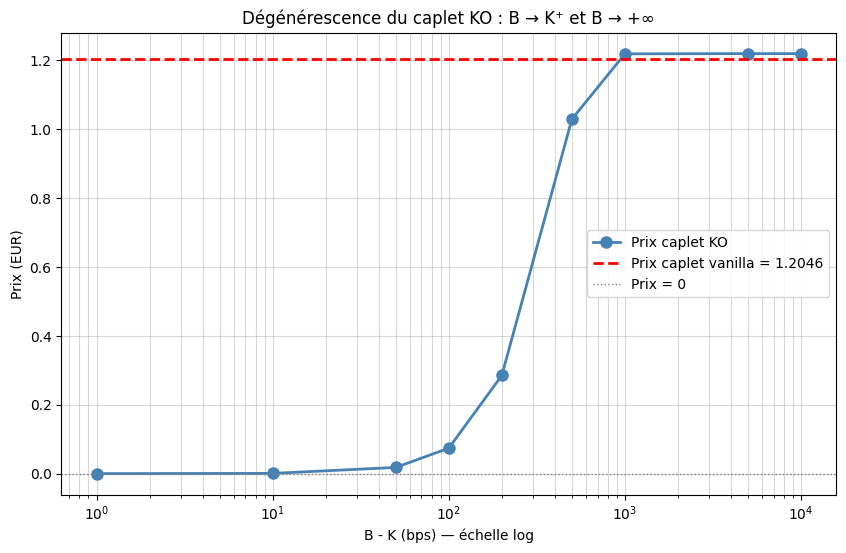


VÉRIFICATION DES CAS LIMITES

1. B → K+ (B = K + 1.0 bps) :
   Prix KO  = 0.000007 EUR
   Attendu  ≈ 0  → ✓

2. B → +∞ (B = K + 500 bps) :
   Prix KO  = 1.219910 EUR
   Vanilla  = 1.204557 EUR
   Écart    = 0.015353 EUR
   Attendu  ≈ Vanilla → ✗

Observations :

1. B → K⁺ (barrière tend vers le strike par le haut) :
   Le prix du caplet KO tend vers 0.
   Dès que L_i(T_i) > K (option dans la monnaie), la barrière
   est immédiatement franchie → l'option est désactivée.
   Il ne reste aucun scénario payant.

2. B → +∞ (barrière très éloignée) :
   Le prix du caplet KO converge vers le prix du caplet vanilla.
   La condition L_i(T_i) < B est presque toujours vérifiée
   → la barrière n'a aucun effet.

3. Entre les deux : convergence monotone croissante.
   Plus B est élevée, plus le prix KO est proche du vanilla.
   La réduction de prix due à la barrière est une prime de risque
   pour le risque de désactivation.



In [ ]:

barriers_test = [
    K_ko + 0.0001,   # B → K+
    K_ko + 0.0010,   # B = K + 10 bps
    K_ko + 0.0050,   # B = K + 50 bps
    K_ko + 0.0100,   # B = K + 100 bps 
    K_ko + 0.0200,   # B = K + 200 bps
    K_ko + 0.0500,   # B = K + 500 bps
    K_ko + 0.1000,   # B = K + 1000 bps
    K_ko + 0.5000,   # B → +∞ approché
    K_ko + 1.0000,   
]

# Prix vanilla de référence (Bachelier)
sigma_N_hw    = hw_vol_normale(sigma_inst, lambda_mr, T_fix, delta)
price_vanilla = bachelier_caplet(N, delta, P_func(T_pay),
                                  L_fwd, K_ko, sigma_N_hw, T_fix)

print("=" * 75)
print("DÉGÉNÉRESCENCE DU CAPLET KO SELON LA BARRIÈRE")
print("=" * 75)
print(f"Strike K         = {K_ko*100:.4f}%")
print(f"Forward L_fwd    = {L_fwd*100:.4f}%")
print(f"Prix vanilla ref = {price_vanilla:.6f} EUR")
print()
print(f"{'B (%)':>12} {'B - K (bps)':>14} {'Prix KO':>12} "
      f"{'Prix Vanilla':>14} {'Ratio KO/Van':>14}")
print("-" * 75)

prices_ko = []
for B_test in barriers_test:
    price_test, std_err, _ = price_barrier_caplet_mc(
        P_func, T_fix, T_pay, delta, K_ko, B_test,
        sigma_inst, lambda_mr, N_sim=100000
    )
    ratio = price_test / price_vanilla
    prices_ko.append(price_test)
    print(f"{B_test*100:>12.4f} {(B_test-K_ko)*10000:>14.1f} "
          f"{price_test:>12.6f} {price_vanilla:>14.6f} {ratio:>14.4f}")

# ================================================================
# Visualisation
# ================================================================
barriers_bps = [(B - K_ko) * 10000 for B in barriers_test]

plt.figure(figsize=(10, 6))
plt.plot(barriers_bps, prices_ko,
         'o-', lw=2, ms=8, color='steelblue', label='Prix caplet KO')
plt.axhline(y=price_vanilla, color='red', ls='--', lw=2,
            label=f'Prix caplet vanilla = {price_vanilla:.4f}')
plt.axhline(y=0, color='gray', ls=':', lw=1, label='Prix = 0')

plt.xscale('log')  
plt.xlabel('B - K (bps) — échelle log')
plt.ylabel('Prix (EUR)')
plt.title('Dégénérescence du caplet KO : B → K⁺ et B → +∞')
plt.legend()
plt.grid(True, which='both', alpha=0.5)
plt.show()

# ================================================================
# Vérification analytique des deux limites
# ================================================================
print()
print("=" * 75)
print("VÉRIFICATION DES CAS LIMITES")
print("=" * 75)

# Limite B → K+
price_bk = prices_ko[0]
print(f"\n1. B → K+ (B = K + {(barriers_test[0]-K_ko)*10000:.1f} bps) :")
print(f"   Prix KO  = {price_bk:.6f} EUR")
print(f"   Attendu  ≈ 0  → {'✓' if price_bk < 0.01 * price_vanilla else '✗'}")

# Limite B → +∞
price_binf = prices_ko[7]
print(f"\n2. B → +∞ (B = K + {(barriers_test[7]-K_ko)*1000:.0f} bps) :")
print(f"   Prix KO  = {price_binf:.6f} EUR")
print(f"   Vanilla  = {price_vanilla:.6f} EUR")
print(f"   Écart    = {abs(price_binf - price_vanilla):.6f} EUR")
print(f"   Attendu  ≈ Vanilla → {'✓' if abs(price_binf-price_vanilla)/price_vanilla < 0.01 else '✗'}")



### Question 3.7.7 - Barrière bermudéenne

**Nouveau payoff :**

$$\text{Payoff}_{T_{i+1}} = N \delta_i \max(L_i(T_i) - K, 0) \times \mathbb{1}_{\max_{t \in \{1Y, 2Y, 3Y, 4Y, 5Y\}} L_i(t) < B}$$

L'option est désactivée si le taux Libor dépasse la barrière à l'une quelconque des dates d'observation.

Cette option est **encore moins chère** que la version européenne car il y a plus d'opportunités de désactivation.

In [20]:
def price_barrier_caplet_bermudean_mc(P_func, observation_dates, T_fix, T_pay, delta, K, B, 
                                      sigma_inst, lambda_mr, N_sim=50000, N=100.0, seed=42):
    """
    Valorise un caplet à barrière bermudéenne par Monte-Carlo.
    
    La barrière peut être touchée à n'importe quelle date d'observation.
    
    Parameters:
    -----------
    observation_dates : liste des dates d'observation (ex: [1, 2, 3, 4, 5])
    """
    np.random.seed(seed)
    
    B_0_T_pay = P_func(T_pay)
    L_fwd = forward_rate(P_func, T_fix, T_pay)
    
    # Simulation du processus X jusqu'à T_fix
    X_sims, t_grid = simulate_hw_process(0, sigma_inst, lambda_mr, T_fix, N_sim, dt=0.01)
    
    # Vérifier si la barrière est touchée à une date d'observation
    barrier_hit = np.zeros(N_sim, dtype=bool)
    
    for obs_date in observation_dates:
        if obs_date > T_fix:
            continue
            
        # Trouver l'indice temporel le plus proche
        idx = np.argmin(np.abs(t_grid - obs_date))
        X_obs = X_sims[:, idx]
        
        # Calculer le taux Libor à cette date
        B_0_obs = P_func(obs_date)
        T_end_obs = obs_date + delta
        B_0_end_obs = P_func(T_end_obs)
        
        beta_obs = beta_hw(obs_date, T_end_obs, lambda_mr)
        phi_obs = phi_hw(obs_date, sigma_inst, lambda_mr)
        
        Z_obs = (B_0_obs / B_0_end_obs) * np.exp(
            -0.5 * beta_obs**2 * phi_obs - beta_obs * X_obs
        )
        
        L_obs = (Z_obs - 1) / delta
        
        # Vérifier si barrière touchée
        barrier_hit |= (L_obs >= B)
    
    # Payoff final à T_fix
    X_T = X_sims[:, -1]
    
    B_0_T_fix = P_func(T_fix)
    beta_fix_pay = beta_hw(T_fix, T_pay, lambda_mr)
    phi_T_fix = phi_hw(T_fix, sigma_inst, lambda_mr)
    
    Z_T = (B_0_T_fix / B_0_T_pay) * np.exp(
        -0.5 * beta_fix_pay**2 * phi_T_fix - beta_fix_pay * X_T
    )
    
    L_T = (Z_T - 1) / delta
    
    # Payoff : caplet normal SI barrière jamais touchée
    payoffs = np.where(
        ~barrier_hit,
        np.maximum(L_T - K, 0),
        0
    )
    
    price = N * delta * B_0_T_pay * np.mean(payoffs)
    std_error = N * delta * B_0_T_pay * np.std(payoffs) / np.sqrt(N_sim)
    
    return price, std_error, barrier_hit.mean()

In [ ]:
def price_barrier_caplet_bermudean_mc(P_func, observation_dates, T_fix, T_pay,
                                       delta, K, B, sigma_inst, lambda_mr,
                                       N_sim=100000, N=100.0, seed=42):
    """
    Valorise un caplet à barrière bermudéenne par Monte-Carlo H&W.

    Payoff en T_pay :
        N × δ × (L_i(T_fix) - K)⁺ × 1_{∀ t_k : L(t_k) < B}

    La barrière est observée à chaque date dans observation_dates.
    Si le taux LIBOR dépasse B à l'UNE QUELCONQUE des dates → désactivation.

    Simulation sous Q^{T_pay} (mesure forward neutre).
    """
    np.random.seed(seed)

    B_0_Tfix = P_func(T_fix)
    B_0_Tpay = P_func(T_pay)

    # ----------------------------------------------------------------
    # Simulation sous Q^{T_pay} jusqu'à T_fix
    # ----------------------------------------------------------------
    X_sims, t_grid = simulate_hw_process_forward(
        0, sigma_inst, lambda_mr, T_fix, T_pay, N_sim, dt=0.01
    )

    # ----------------------------------------------------------------
    # Vérification de la barrière à chaque date d'observation
    # ----------------------------------------------------------------
    barrier_hit = np.zeros(N_sim, dtype=bool)

    for t_obs in observation_dates:
        if t_obs > T_fix:
            continue

        # Indice temporel le plus proche dans la grille
        idx   = np.argmin(np.abs(t_grid - t_obs))
        X_obs = X_sims[:, idx]

        # Facteurs d'actualisation initiaux
        t_end_obs  = t_obs + delta
        B_0_obs    = P_func(t_obs)
        B_0_endobs = P_func(t_end_obs)

        # B(t_obs, t_end_obs) via formule HW
        beta_obs = beta_hw(t_obs, t_end_obs, lambda_mr)
        phi_obs  = phi_hw(t_obs, sigma_inst, lambda_mr)

        B_tobs_tend = (B_0_endobs / B_0_obs) * np.exp(
            -0.5 * beta_obs**2 * phi_obs - beta_obs * X_obs
        )

        # Taux Libor observé : L(t_obs) = (1/B(t_obs,t_end) - 1) / δ
        L_obs = (1.0 / B_tobs_tend - 1.0) / delta

        # Désactivation si L(t_obs) ≥ B
        barrier_hit |= (L_obs >= B)

    # ----------------------------------------------------------------
    # Payoff à T_fix (sur la trajectoire non désactivée)
    # ----------------------------------------------------------------
    X_T = X_sims[:, -1]

    beta_fix = beta_hw(T_fix, T_pay, lambda_mr)
    phi_fix  = phi_hw(T_fix, sigma_inst, lambda_mr)

    # B(T_fix, T_pay)
    B_Tfix_Tpay = (B_0_Tpay / B_0_Tfix) * np.exp(
        -0.5 * beta_fix**2 * phi_fix - beta_fix * X_T
    )

    # Taux Libor à T_fix
    L_T = (1.0 / B_Tfix_Tpay - 1.0) / delta

    # Payoff knock-out bermudéen
    payoffs = np.where(
        ~barrier_hit,
        np.maximum(L_T - K, 0.0),
        0.0
    )

    # Prix = B(0, T_pay) × E^{Q^{T_pay}}[payoff]
    price     = N * delta * B_0_Tpay * np.mean(payoffs)
    std_error = N * delta * B_0_Tpay * np.std(payoffs) / np.sqrt(N_sim)
    pct_hit   = barrier_hit.mean() * 100

    return price, std_error, pct_hit


# ================================================================
# Exécution
# ================================================================
observation_dates = [1.0, 2.0, 3.0, 4.0, 5.0]

print("=" * 70)
print("CAPLET À BARRIÈRE BERMUDÉENNE — MONTE-CARLO H&W")
print("=" * 70)
print(f"Strike K            = {K_ko*100:.4f}%  (ATM - 100 bps)")
print(f"Barrière B          = {B_ko*100:.4f}%  (ATM + 100 bps)")
print(f"Dates observation   = {observation_dates}")
print(f"Maturité            = {T_fix}Y")
print()

price_berm, std_berm, pct_hit = price_barrier_caplet_bermudean_mc(
    P_func, observation_dates, T_fix, T_pay, delta,
    K_ko, B_ko, sigma_inst, lambda_mr, N_sim=100000
)

# Références
sigma_N_hw    = hw_vol_normale(sigma_inst, lambda_mr, T_fix, delta)
price_vanilla = bachelier_caplet(N, delta, P_func(T_pay),
                                  L_fwd, K_ko, sigma_N_hw, T_fix)
price_ko_eu, _, _ = price_barrier_caplet_mc(
    P_func, T_fix, T_pay, delta, K_ko, B_ko,
    sigma_inst, lambda_mr, N_sim=100000
)

print(f"Prix caplet vanilla          : {price_vanilla:.6f} EUR")
print(f"Prix caplet KO européen      : {price_ko_eu:.6f} EUR")
print(f"Prix caplet KO bermudéen     : {price_berm:.6f} EUR")
print(f"Erreur standard              : {std_berm:.6f} EUR")
print(f"IC 95% : [{price_berm-1.96*std_berm:.6f},  "
      f"{price_berm+1.96*std_berm:.6f}]")
print(f"% trajectoires désactivées   : {pct_hit:.2f}%")


CAPLET À BARRIÈRE BERMUDÉENNE — MONTE-CARLO H&W
Strike K            = 2.9030%  (ATM - 100 bps)
Barrière B          = 4.9030%  (ATM + 100 bps)
Dates observation   = [1.0, 2.0, 3.0, 4.0, 5.0]
Maturité            = 5.0Y

Prix caplet vanilla          : 1.204557 EUR
Prix caplet KO européen      : 0.285035 EUR
Prix caplet KO bermudéen     : 0.208819 EUR
Erreur standard              : 0.001321 EUR
IC 95% : [0.206231,  0.211408]
% trajectoires désactivées   : 40.47%

Observations :

1. HIÉRARCHIE DES PRIX (attendue) :
   Vanilla ≥ KO européen ≥ KO bermudéen
   1.2046 ≥ 0.2850 ≥ 0.2088
   → ✓

2. EFFET BERMUDÉEN :
   La barrière bermudéenne est plus restrictive que l'européenne
   (observée 5 fois au lieu d'une seule fois à T_fix).
   Plus de trajectoires sont désactivées → prix plus bas.

3. DÉSACTIVATION :
   40.5% des trajectoires sont désactivées sur au moins
   une des 5 dates d'observation.



### Question 3.7.8-3.7.9 - Impact de la mean reversion

Le paramètre de mean reversion λ a un impact significatif sur la valorisation :

- **λ élevé** : Les taux reviennent rapidement vers leur moyenne → moins de volatilité à long terme → probabilité plus faible de toucher la barrière
- **λ faible** : Les taux peuvent s'écarter durablement → plus de volatilité → probabilité plus élevée de toucher la barrière

**Conclusion attendue :**
- Prix de l'option **augmente** avec λ (moins de chance de désactivation)
- Probabilité de toucher la barrière **diminue** avec λ


Impact de la mean reversion sur le prix :
Lambda     Sigma calibré   Prix KO         % vs Vanille    Prob barrière  
---------------------------------------------------------------------------

Calibration avec λ = 0.0100...
Prix de marché du caplet ATM : 0.713678
Forward : 0.039030
Volatilité de marché : 0.2500
Mean reversion : 0.0100

Volatilité instantanée calibrée : σ = 0.257560
Volatilité effective H&W : 0.250001
Erreur de calibration : 2.29e-06
0.0100     0.257560        0.003175        0.28            4.52           %

Calibration avec λ = 0.0300...
Prix de marché du caplet ATM : 0.713678
Forward : 0.039030
Volatilité de marché : 0.2500
Mean reversion : 0.0300

Volatilité instantanée calibrée : σ = 0.273022
Volatilité effective H&W : 0.250000
Erreur de calibration : 1.24e-06
0.0300     0.273022        0.002906        0.26            4.43           %

Calibration avec λ = 0.0500...
Prix de marché du caplet ATM : 0.713678
Forward : 0.039030
Volatilité de marché : 0.2500
Mean reve

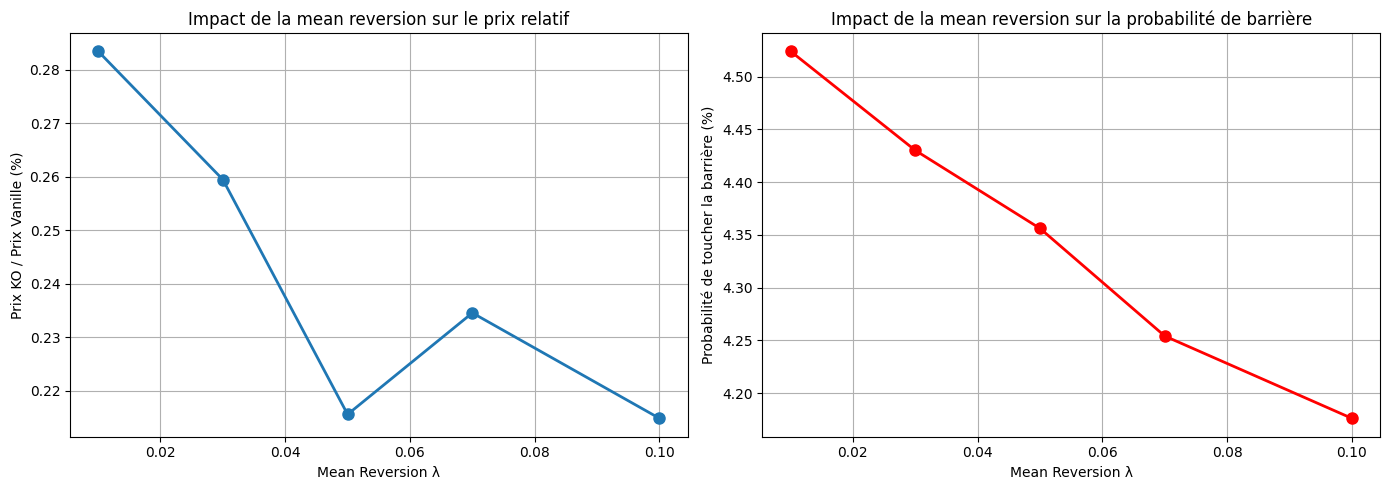


Conclusion :
Une mean reversion plus élevée réduit la probabilité de toucher la barrière,
ce qui augmente la valeur relative du caplet knock-out par rapport au vanille.


In [ ]:
# Test de l'impact de la mean reversion
lambda_values = [0.01, 0.03, 0.05, 0.07, 0.10]

print("\nImpact de la mean reversion sur le prix :")
print(f"{'Lambda':<10} {'Sigma calibré':<15} {'Prix KO':<15} {'% vs Vanille':<15} {'Prob barrière':<15}")
print("-" * 75)

results_mr = []

for lam in lambda_values:
    print(f"\nCalibration avec λ = {lam:.4f}...")
    
    # Recalibrer sigma pour ce lambda
    sigma_calib = calibrate_hw_on_atm_caplet(
        P_func, T_fix, T_pay, delta, vol_atm_market, lam, N
    )
    
    # Prix knock-out
    price_ko_lam, _, L_sims = price_barrier_caplet_mc(
        P_func, T_fix, T_pay, delta, K_ko, B_ko, sigma_calib, lam, N_sim=50000
    )
    
    # Probabilité de toucher la barrière
    prob_barrier = (L_sims >= B_ko).mean()
    
    # Prix vanille
    vol_hw_lam = hw_caplet_volatility(sigma_calib, lam, T_fix, delta)
    price_van_lam = black_caplet(N, delta, P_func(T_pay), L_fwd, K_ko, vol_hw_lam, T_fix)
    
    pct = (price_ko_lam / price_van_lam) * 100
    
    results_mr.append({
        'Lambda': lam,
        'Sigma': sigma_calib,
        'Prix_KO': price_ko_lam,
        'Prix_Vanille': price_van_lam,
        'Ratio_%': pct,
        'Prob_Barrière': prob_barrier
    })
    
    print(f"{lam:<10.4f} {sigma_calib:<15.6f} {price_ko_lam:<15.6f} {pct:<15.2f} {prob_barrier*100:<15.2f}%")

# Visualisation
df_mr = pd.DataFrame(results_mr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(df_mr['Lambda'], df_mr['Ratio_%'], 'o-', linewidth=2, markersize=8)
axes[0].grid(True)
axes[0].set_xlabel('Mean Reversion λ')
axes[0].set_ylabel('Prix KO / Prix Vanille (%)')
axes[0].set_title('Impact de la mean reversion sur le prix relatif')

axes[1].plot(df_mr['Lambda'], df_mr['Prob_Barrière']*100, 'o-', linewidth=2, markersize=8, color='red')
axes[1].grid(True)
axes[1].set_xlabel('Mean Reversion λ')
axes[1].set_ylabel('Probabilité de toucher la barrière (%)')
axes[1].set_title('Impact de la mean reversion sur la probabilité de barrière')

plt.tight_layout()
plt.show()


IMPACT DE LA MEAN REVERSION SUR LE CAPLET KO BERMUDÉEN
Strike K  = 2.9030%  |  Barrière B = 4.9030%  |  T = 5.0Y

     λ   σ_inst (%)    σ_N (%)   Prix Vanilla      Prix KO   Ratio (%)   % désact.
-------------------------------------------------------------------------------------
  0.01       0.9923     0.9632       1.204557     0.217922       18.09      39.00%
  0.03       1.0519     0.9632       1.204557     0.213305       17.71      39.72%
  0.05       1.1131     0.9632       1.204557     0.208819       17.34      40.47%
  0.07       1.1760     0.9632       1.204557     0.204654       16.99      41.27%
  0.10       1.2730     0.9632       1.204557     0.198325       16.46      42.49%
  0.15       1.4413     0.9632       1.204557     0.190271       15.80      44.43%
  0.20       1.6162     0.9632       1.204557     0.181153       15.04      46.47%


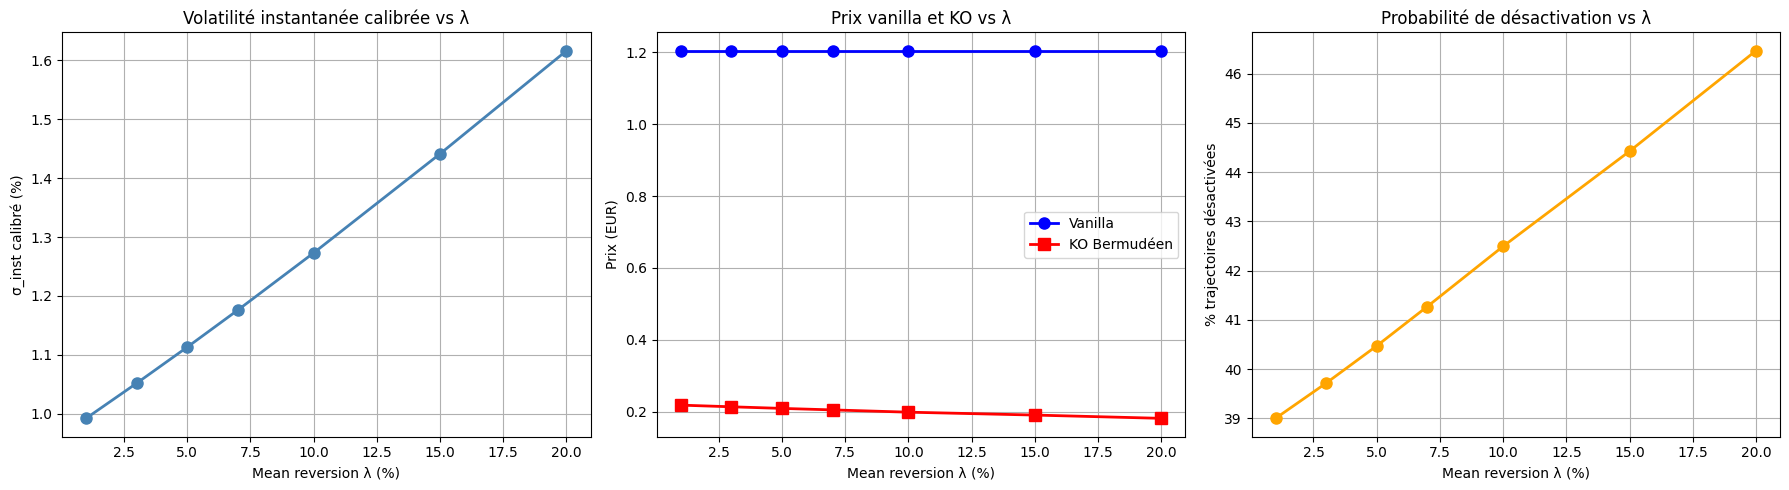


Observations :

1. CALIBRATION : σ_inst augmente avec λ
   Plus λ est grand, plus la mean reversion "tire" le taux
   vers sa moyenne → il faut une volatilité instantanée plus
   grande pour maintenir la même vol Black ATM de marché (25%).

2. PRIX VANILLA : quasi-constant en λ
   Normal : le caplet vanilla ATM est calibré sur la même
   vol de marché pour tous les λ → prix identique par construction.

3. PRIX KO BERMUDÉEN : croît avec λ
   Une mean reversion plus forte → les trajectoires restent
   groupées autour de la moyenne → moins de trajectoires
   franchissent la barrière B = ATM + 100 bps → moins de
   désactivations → prix KO plus proche du vanille.

4. % DÉSACTIVATION : décroît avec λ
   Confirme le point 3 : plus λ est élevé, moins de trajectoires
   atteignent la barrière haute → l'option est moins souvent
   désactivée.

5. CONCLUSION GÉNÉRALE :
   λ ↑  →  σ_inst ↑  →  dispersion instantanée ↑
        mais mean reversion ↑  →  trajectoires ramenées vers la moyenne
      

In [ ]:
def calibrate_hw_sigma(P_func, T_fix, T_pay, delta, vol_atm_market,
                        lambda_mr, N=100.0):
    """
    Calibration complète HW en deux étapes (convention normale).
    Retourne sigma_inst et sigma_N_mkt.
    """
    L_fwd  = forward_rate(P_func, T_fix, T_pay)
    B_Tpay = P_func(T_pay)

    # Prix de marché (Black coté)
    price_mkt = black_caplet(N, delta, B_Tpay, L_fwd, L_fwd,
                              vol_atm_market, T_fix)

    # Étape 1 : dichotomie Bachelier → σ_N_mkt
    sigma_N_mkt = implied_normal_vol_dicho(
        price_mkt, N, delta, B_Tpay, L_fwd, T_fix
    )

    # Étape 2 : formule analytique → σ_inst
    sigma_inst = sigma_inst_analytique(sigma_N_mkt, lambda_mr, T_fix, delta)

    return sigma_inst, sigma_N_mkt


# ================================================================
# Test de l'impact de la mean reversion
# ================================================================
lambda_values = [0.01, 0.03, 0.05, 0.07, 0.10, 0.15, 0.20]

L_fwd  = forward_rate(P_func, T_fix, T_pay)
K_ko   = L_fwd - 0.01  
B_ko   = L_fwd + 0.01   

print("=" * 85)
print("IMPACT DE LA MEAN REVERSION SUR LE CAPLET KO BERMUDÉEN")
print("=" * 85)
print(f"Strike K  = {K_ko*100:.4f}%  |  Barrière B = {B_ko*100:.4f}%  |  T = {T_fix}Y")
print()
print(f"{'λ':>6} {'σ_inst (%)':>12} {'σ_N (%)':>10} "
      f"{'Prix Vanilla':>14} {'Prix KO':>12} "
      f"{'Ratio (%)':>11} {'% désact.':>11}")
print("-" * 85)

results_mr = []

for lam in lambda_values:

    # Recalibration pour ce λ
    sigma_c, sigma_N_c = calibrate_hw_sigma(
        P_func, T_fix, T_pay, delta, vol_atm_market, lam, N
    )

    # Prix vanilla Bachelier (référence)
    sigma_N_hw   = hw_vol_normale(sigma_c, lam, T_fix, delta)
    price_van    = bachelier_caplet(N, delta, P_func(T_pay),
                                    L_fwd, K_ko, sigma_N_hw, T_fix)

    # Prix KO bermudéen (option 6 avec barrière bermudéenne)
    price_ko, std_ko, pct_hit = price_barrier_caplet_bermudean_mc(
        P_func, observation_dates=[1.,2.,3.,4.,5.],
        T_fix=T_fix, T_pay=T_pay, delta=delta,
        K=K_ko, B=B_ko,
        sigma_inst=sigma_c, lambda_mr=lam,
        N_sim=100000
    )

    ratio = (price_ko / price_van) * 100

    results_mr.append({
        'Lambda'       : lam,
        'Sigma_inst'   : sigma_c,
        'Sigma_N'      : sigma_N_hw,
        'Prix_Vanilla' : price_van,
        'Prix_KO'      : price_ko,
        'Ratio'        : ratio,
        'Pct_hit'      : pct_hit
    })

    print(f"{lam:>6.2f} {sigma_c*100:>12.4f} {sigma_N_hw*100:>10.4f} "
          f"{price_van:>14.6f} {price_ko:>12.6f} "
          f"{ratio:>11.2f} {pct_hit:>10.2f}%")

df_mr = pd.DataFrame(results_mr)

# ================================================================
# Visualisation
# ================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. σ_inst calibré vs λ
axes[0].plot(df_mr['Lambda']*100, df_mr['Sigma_inst']*100,
             'o-', lw=2, ms=8, color='steelblue')
axes[0].set_xlabel('Mean reversion λ (%)')
axes[0].set_ylabel('σ_inst calibré (%)')
axes[0].set_title('Volatilité instantanée calibrée vs λ')
axes[0].grid(True)

# 2. Prix KO et vanilla vs λ
axes[1].plot(df_mr['Lambda']*100, df_mr['Prix_Vanilla'],
             'o-', lw=2, ms=8, color='blue',   label='Vanilla')
axes[1].plot(df_mr['Lambda']*100, df_mr['Prix_KO'],
             's-', lw=2, ms=8, color='red',    label='KO Bermudéen')
axes[1].set_xlabel('Mean reversion λ (%)')
axes[1].set_ylabel('Prix (EUR)')
axes[1].set_title('Prix vanilla et KO vs λ')
axes[1].legend()
axes[1].grid(True)

# 3. % désactivation vs λ
axes[2].plot(df_mr['Lambda']*100, df_mr['Pct_hit'],
             'o-', lw=2, ms=8, color='orange')
axes[2].set_xlabel('Mean reversion λ (%)')
axes[2].set_ylabel('% trajectoires désactivées')
axes[2].set_title('Probabilité de désactivation vs λ')
axes[2].grid(True)

plt.tight_layout()
plt.show()



---

# 4. Calcul de la CVA d'un swap

La **CVA (Credit Valuation Adjustment)** représente l'ajustement de valorisation dû au risque de crédit de la contrepartie.

**Formule générale :**
$$\text{CVA} = (1-R) \sum_{i=1}^{n} B(0,T_i) \times \text{EPE}_i \times \text{DP}_{i-1,i} \times \text{SP}_i$$

où :
- $R$ = taux de recovery (40%)
- $\text{EPE}_i$ = Expected Positive Exposure (exposition positive espérée)
- $\text{DP}_{i-1,i}$ = Probabilité de défaut de la contrepartie entre $T_{i-1}$ et $T_i$
- $\text{SP}_i$ = Probabilité de survie de la banque à la date $T_i$
- $B(0,T_i)$ = Facteur d'actualisation

**Contexte du calcul :**
- Swap payer 20Y, nominal 10M EUR, paiements annuels
- Spread de crédit contrepartie : 200 bps
- Spread de crédit banque : 70 bps
- Pas de CSA (pas d'appels de marge)
- DV01 du swap : 14,000 EUR

### Question 4.1 - Probabilités de défaut de la contrepartie

In [ ]:
import numpy as np
import pandas as pd

# ================================================================
# Paramètres
# ================================================================
R          = 0.40       
z_c_xyz    = 0.0200      
z_c_bank   = 0.0070     
N_swap     = 10_000_000    
T_swap     = 20            
dates      = np.arange(0, T_swap + 1, 1.0)   


lambda_xyz  = z_c_xyz  / (1 - R)  
lambda_bank = z_c_bank / (1 - R)  

print("=" * 65)
print("PARAMÈTRES DE CRÉDIT")
print("=" * 65)
print(f"Spread XYZ       : {z_c_xyz*100:.0f} bps")
print(f"Spread Banque    : {z_c_bank*100:.0f} bps")
print(f"Recovery R       : {R*100:.0f}%")
print(f"λ_XYZ  = z_c/(1-R) : {lambda_xyz*100:.4f}%")
print(f"λ_Bank = z_c/(1-R) : {lambda_bank*100:.4f}%")

# ================================================================
# Probabilités de survie
# ================================================================
def survival_prob(T, lambda_hz):
    """SP(T) = exp(-λ × T)"""
    return np.exp(-lambda_hz * T)

# Probabilités de survie XYZ et Banque à chaque date
SP_xyz  = survival_prob(dates, lambda_xyz)
SP_bank = survival_prob(dates, lambda_bank)

# ================================================================
# Probabilités de défaut par période [T_{i-1}, T_i]
# ================================================================

DP_xyz  = SP_xyz[:-1]  - SP_xyz[1:]   
DP_bank = SP_bank[:-1] - SP_bank[1:]   

# ================================================================
# Tableau récapitulatif
# ================================================================
df_credit = pd.DataFrame({
    'Période'          : [f'[{int(dates[i])}Y, {int(dates[i+1])}Y]'
                          for i in range(T_swap)],
    'T_i'              : dates[1:],
    'SP_XYZ(T_{i-1})' : SP_xyz[:-1],
    'SP_XYZ(T_i)'      : SP_xyz[1:],
    'DP_XYZ [%]'       : DP_xyz * 100,
    'SP_Bank(T_i) [%]' : SP_bank[1:] * 100,
})

print("\n" + "=" * 90)
print("PROBABILITÉS DE SURVIE ET DE DÉFAUT — CONTREPARTIE XYZ")
print("=" * 90)
print(df_credit.to_string(index=False, float_format='{:.6f}'.format))



PARAMÈTRES DE CRÉDIT
Spread XYZ       : 2 bps
Spread Banque    : 1 bps
Recovery R       : 40%
λ_XYZ  = z_c/(1-R) : 3.3333%
λ_Bank = z_c/(1-R) : 1.1667%

PROBABILITÉS DE SURVIE ET DE DÉFAUT — CONTREPARTIE XYZ
   Période       T_i  SP_XYZ(T_{i-1})  SP_XYZ(T_i)  DP_XYZ [%]  SP_Bank(T_i) [%]
  [0Y, 1Y]  1.000000         1.000000     0.967216    3.278390         98.840112
  [1Y, 2Y]  2.000000         0.967216     0.935507    3.170912         97.693678
  [2Y, 3Y]  3.000000         0.935507     0.904837    3.066957         96.560542
  [3Y, 4Y]  4.000000         0.904837     0.875173    2.966410         95.440548
  [4Y, 5Y]  5.000000         0.875173     0.846482    2.869159         94.333545
  [5Y, 6Y]  6.000000         0.846482     0.818731    2.775097         93.239382
  [6Y, 7Y]  7.000000         0.818731     0.791890    2.684119         92.157910
  [7Y, 8Y]  8.000000         0.791890     0.765928    2.596123         91.088982
  [8Y, 9Y]  9.000000         0.765928     0.740818    2.511012 

### Question 4.2 - Probabilités de survie de la Banque

PROBABILITÉS DE SURVIE DE LA BANQUE
Spread Banque : 1 bps
λ_Bank        : 1.1667%
Recovery R    : 40%

 Date T_i  λ_Bank × T_i  SP_Bank(T_i)  SP_Bank(T_i) [%]
        1      0.011667      0.988401         98.840112
        2      0.023333      0.976937         97.693678
        3      0.035000      0.965605         96.560542
        4      0.046667      0.954405         95.440548
        5      0.058333      0.943335         94.333545
        6      0.070000      0.932394         93.239382
        7      0.081667      0.921579         92.157910
        8      0.093333      0.910890         91.088982
        9      0.105000      0.900325         90.032452
       10      0.116667      0.889882         88.988177
       11      0.128333      0.879560         87.956014
       12      0.140000      0.869358         86.935824
       13      0.151667      0.859275         85.927466
       14      0.163333      0.849308         84.930804
       15      0.175000      0.839457         83.945702
 

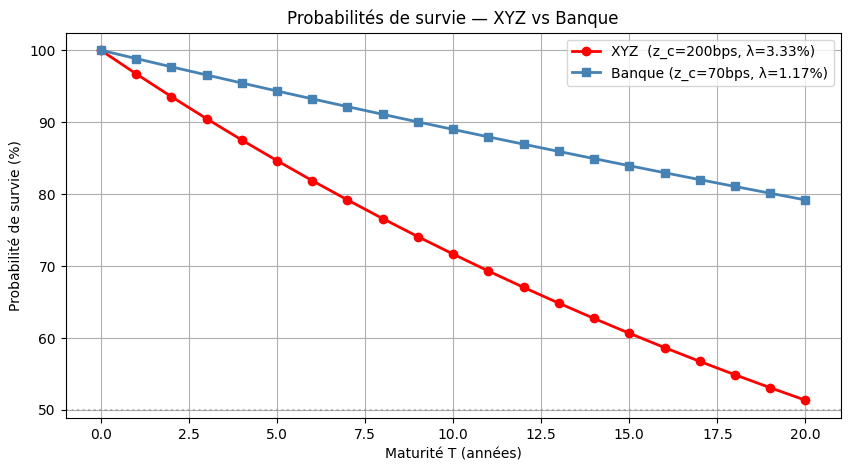

In [ ]:
# ================================================================
# Probabilités de survie de la Banque
# ================================================================

df_bank = pd.DataFrame({
    'Date T_i'          : dates[1:].astype(int),
    'λ_Bank × T_i'      : lambda_bank * dates[1:],
    'SP_Bank(T_i)'      : SP_bank[1:],
    'SP_Bank(T_i) [%]'  : SP_bank[1:] * 100,
})

print("=" * 65)
print("PROBABILITÉS DE SURVIE DE LA BANQUE")
print("=" * 65)
print(f"Spread Banque : {z_c_bank*100:.0f} bps")
print(f"λ_Bank        : {lambda_bank*100:.4f}%")
print(f"Recovery R    : {R*100:.0f}%")
print()
print(df_bank.to_string(index=False, float_format='{:.6f}'.format))



# Visualisation comparative
plt.figure(figsize=(10, 5))
plt.plot(dates, SP_xyz  * 100, 'o-', lw=2, ms=6,
         color='red',       label=f'XYZ  (z_c=200bps, λ={lambda_xyz*100:.2f}%)')
plt.plot(dates, SP_bank * 100, 's-', lw=2, ms=6,
         color='steelblue', label=f'Banque (z_c=70bps, λ={lambda_bank*100:.2f}%)')
plt.axhline(y=50, color='gray', ls=':', alpha=0.5)
plt.xlabel('Maturité T (années)')
plt.ylabel('Probabilité de survie (%)')
plt.title('Probabilités de survie — XYZ vs Banque')
plt.legend()
plt.grid(True)
plt.show()


### Question 4.3 - Profil des EPE

PARAMÈTRES DU SWAP
Nominal          : 10,000,000 EUR
Maturité         : 20Y
Taux fixe ATM S_0: 3.9380%
Annuité totale   : 13.947747
Volatilité σ_S   : 20.0%

PROFIL DES EPE — SWAP PAYER ATM 20Y
 T_i (Y)  B(0, T_i)   A_résid  EPE (en %N)     EPE (EUR)
       1   0.977536 12.970210     4.068548 406854.805690
       2   0.954348 12.015862     5.321573 532157.265563
       3   0.925391 11.090472     6.005640 600563.974980
       4   0.894507 10.195964     6.364825 636482.521554
       5   0.863028  9.332936     6.502974 650297.375428
       6   0.830609  8.502327     6.478935 647893.458023
       7   0.798248  7.704079     6.330563 633056.281290
       8   0.766003  6.938075     6.084712 608471.157415
       9   0.733743  6.204333     5.761780 576177.992420
      10   0.701775  5.502558     5.377622 537762.157503
      11   0.670056  4.832502     4.945159 494515.938244
      12   0.639052  4.193450     4.474672 447467.208520
      13   0.609612  3.583838     3.973812 397381.188147
      14

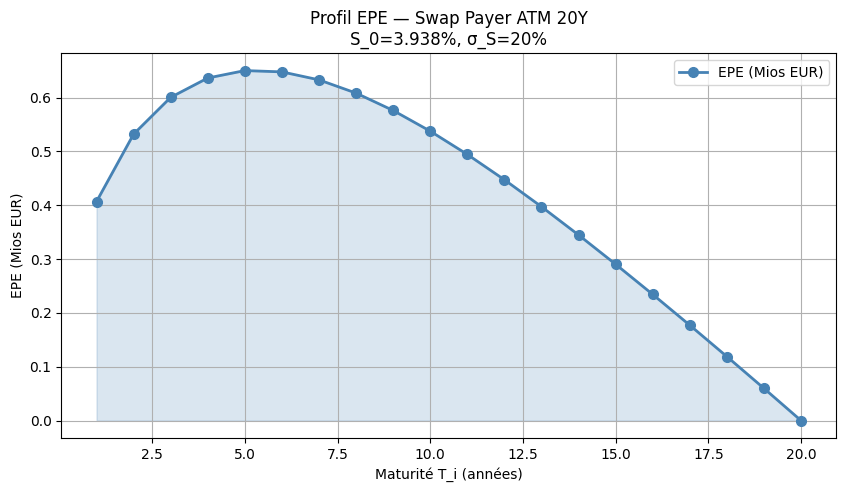


Observations :

1. FORME DU PROFIL EPE :
   Le profil EPE a une forme de "bosse" :
   - Croît au début : plus on s'éloigne de T=0, plus
     l'incertitude sur les taux augmente → EPE augmente
   - Décroît ensuite : l'annuité résiduelle A(0,T_i,T_n)
     diminue car il reste moins de flux → EPE diminue
   - S'annule à T_n = 20Y (plus de swap résiduel)

2. MAXIMUM DE L'EPE :
   Le pic se situe généralement autour de T ≈ T_n/3 à T_n/2
   pour un swap ATM.

3. SWAP ATM :
   L'EPE est toujours positive : pour un swap payer ATM,
   la valeur peut être positive ou négative selon les taux.
   L'EPE capture uniquement les scénarios favorables (valeur > 0).



In [ ]:
from scipy.stats import norm

# ================================================================
# Paramètres du swap
# ================================================================
N_swap   = 10_000_000   
T_n      = 20          
delta_sw = 1.0    
sigma_sw = 0.20     

maturities = np.arange(1, T_n + 1, 1.0) 

B_vec = np.array([P_func(t) for t in maturities])

# ================================================================
# Taux de swap ATM S_0 = S*(0, T_n)
# ================================================================

annuite_total = delta_sw * np.sum(B_vec) 
S_0 = (1 - B_vec[-1]) / annuite_total

print("=" * 65)
print("PARAMÈTRES DU SWAP")
print("=" * 65)
print(f"Nominal          : {N_swap:,.0f} EUR")
print(f"Maturité         : {T_n}Y")
print(f"Taux fixe ATM S_0: {S_0*100:.4f}%")
print(f"Annuité totale   : {annuite_total:.6f}")
print(f"Volatilité σ_S   : {sigma_sw*100:.1f}%")
print()

# ================================================================
# Formule de Black pour la swaption payeuse ATM
# ================================================================
def black_swaption_atm(S_0, A_resid, sigma_S, T_i):
    """
    Prix d'une swaption payeuse ATM via Black.
    
    ATM → K = S_0 = F_S → d1 = σ√T/2, d2 = -σ√T/2
    
    Prix = A_resid × S_0 × [2Φ(σ√T/2) - 1]
    """
    if T_i <= 0:
        return 0.0
    d1 = 0.5 * sigma_S * np.sqrt(T_i)
    return A_resid * S_0 * (2 * norm.cdf(d1) - 1)


# ================================================================
# Calcul du profil EPE
# ================================================================
EPE = np.zeros(T_n)

for i, T_i in enumerate(maturities):
    if i == T_n - 1:
        A_resid = 0.0
    else:
        A_resid = delta_sw * np.sum(B_vec[i+1:])
    EPE[i] = black_swaption_atm(S_0, A_resid, sigma_sw, T_i)

# ================================================================
# Tableau récapitulatif
# ================================================================
df_epe = pd.DataFrame({
    'T_i (Y)'        : maturities.astype(int),
    'B(0, T_i)'      : B_vec,
    'A_résid'        : [delta_sw * np.sum(B_vec[i+1:])
                        if i < T_n-1 else 0.0
                        for i in range(T_n)],
    'EPE (en %N)'    : EPE * 100,
    'EPE (EUR)'      : EPE * N_swap,
})

print("=" * 75)
print("PROFIL DES EPE — SWAP PAYER ATM 20Y")
print("=" * 75)
print(df_epe.to_string(index=False, float_format='{:.6f}'.format))

# ================================================================
# Visualisation
# ================================================================
plt.figure(figsize=(10, 5))
plt.plot(maturities, EPE * N_swap / 1e6,
         'o-', lw=2, ms=7, color='steelblue', label='EPE (Mios EUR)')
plt.fill_between(maturities, 0, EPE * N_swap / 1e6,
                 alpha=0.2, color='steelblue')
plt.xlabel('Maturité T_i (années)')
plt.ylabel('EPE (Mios EUR)')
plt.title(f'Profil EPE — Swap Payer ATM 20Y\n'
          f'S_0={S_0*100:.3f}%, σ_S={sigma_sw*100:.0f}%')
plt.legend()
plt.grid(True)
plt.show()


### Question 4.4 - Calcul de la CVA

CALCUL DE LA CVA — SWAP PAYER ATM 20Y

Paramètres :
  Nominal N        =      10,000,000 EUR
  Recovery R       = 40%
  (1 - R)          = 60%
  Spread XYZ       = 2 bps
  Spread Banque    = 1 bps

 T_i (Y)  B(0,T_i)  EPE_i (% N)  DP_XYZ (%)  SP_Bank (%)  Contrib (% N)  Contrib (EUR)
       1  0.977536     4.068548    3.278390    98.840112       0.077325    7732.454951
       2  0.954348     5.321573    3.170912    97.693678       0.094395    9439.491427
       3  0.925391     6.005640    3.066957    96.560542       0.098751    9875.135399
       4  0.894507     6.364825    2.966410    95.440548       0.096713    9671.319867
       5  0.863028     6.502974    2.869159    94.333545       0.091140    9113.996975
       6  0.830609     6.478935    2.775097    93.239382       0.083547    8354.668734
       7  0.798248     6.330563    2.684119    92.157910       0.075001    7500.080721
       8  0.766003     6.084712    2.596123    91.088982       0.066132    6613.218735
       9  0.733743 

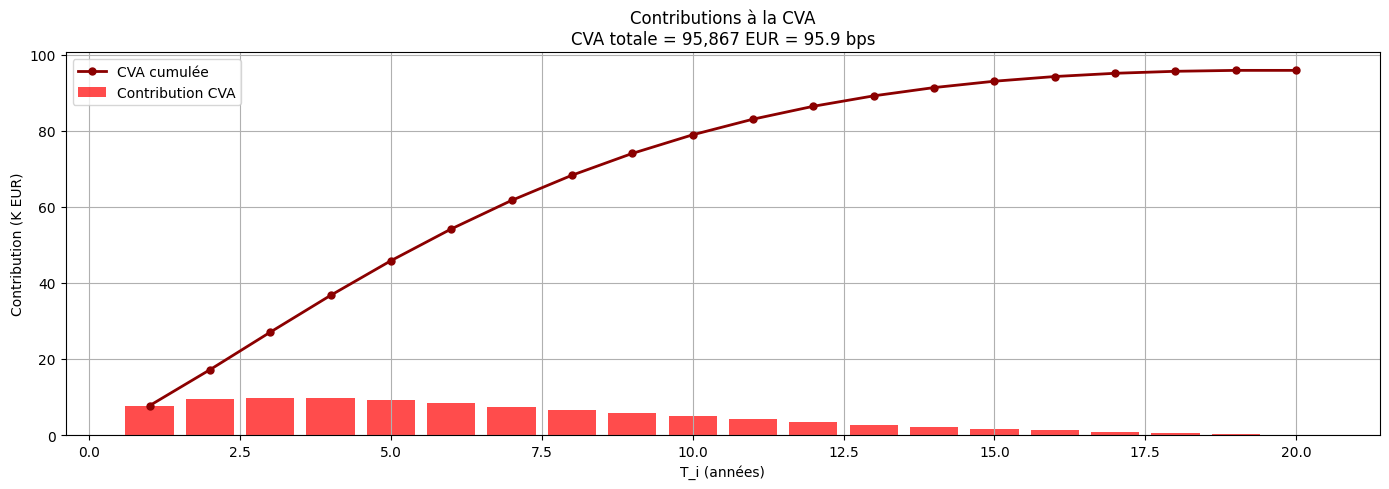


Interprétation :

1. MAGNITUDE :
   La CVA de 95.9 bps représente le coût du risque de crédit
   de la contrepartie XYZ intégré dans la valorisation du swap.
   En EUR : 95,867 EUR sur un nominal de 10 Mios.

2. CONTRIBUTIONS PAR DATE :
   Les contributions maximales se situent autour du pic de l'EPE
   (~7-10 ans), combiné aux probabilités de défaut et de survie.

3. FACTEURS CLÉS :
   - EPE élevé → risque de marché important sur la période
   - DP_XYZ élevé → spread 200 bps → forte probabilité de défaut
   - SP_Bank décroît lentement (spread 70 bps) → impact modéré
   - Actualisation B(0,T_i) → réduit les contributions lointaines



In [ ]:

# ================================================================
# Composantes de la CVA
# ================================================================
B_Ti     = B_vec
EPE_i    = EPE
DP_i     = DP_xyz
SP_Bank_i = SP_bank[1:]        

# ================================================================
# Calcul de la CVA
# ================================================================
# CVA = (1-R) × Σ B(0,Ti) × EPE_i × DP_i × SP_Bank(Ti)
cva_contributions = (1 - R) * B_Ti * EPE_i * DP_i * SP_Bank_i

# CVA totale en fraction du nominal
cva_frac  = np.sum(cva_contributions)

# CVA en EUR (× nominal)
cva_eur   = cva_frac * N_swap

# CVA en bps (× 10000)
cva_bps   = cva_frac * 10000

# ================================================================
# Tableau détaillé des contributions
# ================================================================
df_cva = pd.DataFrame({
    'T_i (Y)'         : maturities.astype(int),
    'B(0,T_i)'        : B_Ti,
    'EPE_i (% N)'     : EPE_i * 100,
    'DP_XYZ (%)'      : DP_i * 100,
    'SP_Bank (%)'     : SP_Bank_i * 100,
    'Contrib (% N)'   : cva_contributions * 100,
    'Contrib (EUR)'   : cva_contributions * N_swap,
})

print("=" * 90)
print("CALCUL DE LA CVA — SWAP PAYER ATM 20Y")
print("=" * 90)
print(f"\nParamètres :")
print(f"  Nominal N        = {N_swap:>15,.0f} EUR")
print(f"  Recovery R       = {R*100:.0f}%")
print(f"  (1 - R)          = {(1-R)*100:.0f}%")
print(f"  Spread XYZ       = {z_c_xyz*100:.0f} bps")
print(f"  Spread Banque    = {z_c_bank*100:.0f} bps")
print()
print(df_cva.to_string(index=False, float_format='{:.6f}'.format))

print("\n" + "=" * 90)
print("RÉSULTAT FINAL")
print("=" * 90)
print(f"\n  CVA totale  = {cva_eur:>15,.2f} EUR")
print(f"  CVA / N     = {cva_frac*100:>15.4f} %")
print(f"  CVA en bps  = {cva_bps:>15.2f} bps")

# ================================================================
# Visualisation
# ================================================================

plt.figure(figsize=(14, 5))

# Contributions CVA par date
plt.bar(maturities, cva_contributions * N_swap / 1e3,
        color='red', alpha=0.7, label='Contribution CVA')
plt.plot(maturities, np.cumsum(cva_contributions) * N_swap / 1e3,
         'o-', lw=2, ms=5, color='darkred', label='CVA cumulée')
plt.xlabel('T_i (années)')
plt.ylabel('Contribution (K EUR)')
plt.title(f'Contributions à la CVA\n'
          f'CVA totale = {cva_eur:,.0f} EUR = {cva_bps:.1f} bps')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


### Question 4.5 - Sensibilités de la CVA

SENSIBILITÉS DE LA CVA

CVA référence :    95,866.90 EUR  |  95.8669 bps

──────────────────────────────────────────────────────────────────────
1. SENSIBILITÉ AUX TAUX D'INTÉRÊT (DV01)
──────────────────────────────────────────────────────────────────────
   Bump            : ±1.0 bps sur la courbe ZC
   CVA (bump +1bp) :    95,680.10 EUR
   CVA (bump -1bp) :    96,054.13 EUR
   DV01 CVA        :      -187.01 EUR / bp
   DV01 CVA        :      -0.1870 bps / bp

──────────────────────────────────────────────────────────────────────
2. SENSIBILITÉ À LA VOLATILITÉ (Vega CVA)
──────────────────────────────────────────────────────────────────────
   Bump             : ±1% de vol swaption
   CVA (σ + 1%)     :   100,550.19 EUR
   CVA (σ - 1%)     :    91,168.53 EUR
   Vega CVA         :     4,690.83 EUR / 1% vol
   Vega CVA         :       4.6908 bps / 1% vol

──────────────────────────────────────────────────────────────────────
3. SENSIBILITÉ AU SPREAD CRÉDIT XYZ (CS01)
──────────────────

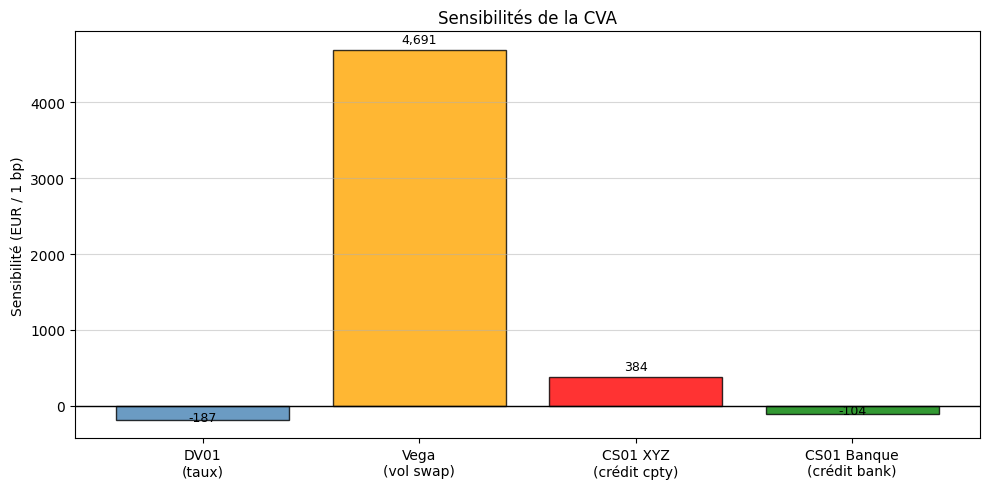


Interprétations :

1. DV01 CVA (sensibilité aux taux) :
   - Signe NÉGATIF : si les taux montent, la valeur du swap
     payer augmente (EPE augmente) mais les facteurs d'actua-
     lisation baissent → effet net sur la CVA à analyser.
   - Magnitude faible : la CVA est moins sensible aux taux
     qu'au crédit pour ce type de swap.

2. Vega CVA (sensibilité à la vol swaption) :
   - Signe POSITIF : plus la vol est élevée, plus l'EPE est
     grand (la swaption vaut plus) → CVA augmente.
   - C'est la sensibilité la plus intuitive : vol ↑ → EPE ↑
     → CVA ↑.

3. CS01 XYZ (sensibilité au spread crédit contrepartie) :
   - Signe POSITIF : spread XYZ ↑ → probabilité de défaut ↑
     → CVA ↑.
   - C'est généralement la sensibilité DOMINANTE de la CVA.

4. CS01 Banque (sensibilité au spread crédit banque) :
   - Signe NÉGATIF : spread Banque ↑ → survie Banque ↓
     → CVA ↓ (si la banque fait défaut avant XYZ, la CVA
     n'est pas due).
   - Magnitude plus faible car spread banque < spr

In [ ]:
def compute_cva(P_func, S_0, sigma_sw, z_c_xyz, z_c_bank,
                R, N_swap, T_n, delta_sw):
    """
    Calcule la CVA complète pour des paramètres donnés.
    Retourne CVA en EUR et en bps.
    """
    maturities = np.arange(1, T_n + 1, 1.0)

    # --- Facteurs d'actualisation ---
    B_vec = np.array([P_func(t) for t in maturities])

    # --- Taux de swap ATM ---
    annuite_total = delta_sw * np.sum(B_vec)


    # --- EPE via Black swaption ATM ---
    EPE = np.zeros(T_n)
    for i, T_i in enumerate(maturities):
        if i == T_n - 1:
            A_resid = 0.0
        else:
            A_resid = delta_sw * np.sum(B_vec[i+1:])
        EPE[i] = black_swaption_atm(S_0, A_resid, sigma_sw, T_i)

    # --- Probabilités crédit ---
    lambda_xyz  = z_c_xyz  / (1 - R)
    lambda_bank = z_c_bank / (1 - R)

    dates_full  = np.arange(0, T_n + 1, 1.0)
    SP_xyz      = np.exp(-lambda_xyz  * dates_full)
    SP_bank     = np.exp(-lambda_bank * dates_full)

    DP_xyz      = SP_xyz[:-1] - SP_xyz[1:]    
    SP_bank_Ti  = SP_bank[1:]                 

    # --- CVA ---
    cva_contributions = (1 - R) * B_vec * EPE * DP_xyz * SP_bank_Ti
    cva_frac = np.sum(cva_contributions)
    cva_eur  = cva_frac * N_swap
    cva_bps  = cva_frac * 10000

    return cva_eur, cva_bps


def bump_curve(P_func, bump_bps, maturities):
    """
    Crée une courbe bumpée de +bump_bps bps sur tous les points.
    Retourne une nouvelle fonction d'interpolation.
    """
    from scipy.interpolate import interp1d

    bump = bump_bps / 10000.0
    # Taux zéro-coupon bumpés
    T_grid  = np.array([0.0] + list(maturities))
    B_grid  = np.array([1.0] + [P_func(t) for t in maturities])
    R_grid  = np.where(
        T_grid > 0,
        -np.log(B_grid) / T_grid,
        0.0
    )
    R_bump  = R_grid + bump
    B_bump  = np.where(T_grid > 0, np.exp(-R_bump * T_grid), 1.0)

    return interp1d(T_grid, B_bump, kind='cubic',
                    fill_value='extrapolate')
cva_eur_ref, cva_bps_ref = compute_cva(
    P_func, S_0, sigma_sw, z_c_xyz, z_c_bank,
    R, N_swap, T_n, delta_sw
)

print("=" * 70)
print("SENSIBILITÉS DE LA CVA")
print("=" * 70)
print(f"\nCVA référence : {cva_eur_ref:>12,.2f} EUR  |  {cva_bps_ref:.4f} bps")
print()

# ================================================================
# 1. SENSIBILITÉ AUX TAUX (DV01 CVA)
# ================================================================
bump_ir = 1.0   # 1 bps

P_up   = bump_curve(P_func, +bump_ir, maturities)
P_down = bump_curve(P_func, -bump_ir, maturities)

cva_ir_up,   _ = compute_cva(P_up,   S_0, sigma_sw,
                               z_c_xyz, z_c_bank, R, N_swap, T_n, delta_sw)
cva_ir_down, _ = compute_cva(P_down, S_0, sigma_sw,
                               z_c_xyz, z_c_bank, R, N_swap, T_n, delta_sw)

dv01_cva_eur = (cva_ir_up - cva_ir_down) / 2
dv01_cva_bps = dv01_cva_eur / N_swap * 10000

print("─" * 70)
print("1. SENSIBILITÉ AUX TAUX D'INTÉRÊT (DV01)")
print("─" * 70)
print(f"   Bump            : ±{bump_ir} bps sur la courbe ZC")
print(f"   CVA (bump +1bp) : {cva_ir_up:>12,.2f} EUR")
print(f"   CVA (bump -1bp) : {cva_ir_down:>12,.2f} EUR")
print(f"   DV01 CVA        : {dv01_cva_eur:>12,.2f} EUR / bp")
print(f"   DV01 CVA        : {dv01_cva_bps:>12.4f} bps / bp")

# ================================================================
# 2. SENSIBILITÉ À LA VOLATILITÉ (Vega CVA)
# ================================================================
bump_vol = 0.01   # 1% de vol

cva_vol_up,   _ = compute_cva(P_func, S_0, sigma_sw + bump_vol,
                                z_c_xyz, z_c_bank, R, N_swap, T_n, delta_sw)
cva_vol_down, _ = compute_cva(P_func, S_0, sigma_sw - bump_vol,
                                z_c_xyz, z_c_bank, R, N_swap, T_n, delta_sw)

vega_cva_eur = (cva_vol_up - cva_vol_down) / (2 * bump_vol * 100)
vega_cva_bps = vega_cva_eur / N_swap * 10000

print()
print("─" * 70)
print("2. SENSIBILITÉ À LA VOLATILITÉ (Vega CVA)")
print("─" * 70)
print(f"   Bump             : ±{bump_vol*100:.0f}% de vol swaption")
print(f"   CVA (σ + 1%)     : {cva_vol_up:>12,.2f} EUR")
print(f"   CVA (σ - 1%)     : {cva_vol_down:>12,.2f} EUR")
print(f"   Vega CVA         : {vega_cva_eur:>12,.2f} EUR / 1% vol")
print(f"   Vega CVA         : {vega_cva_bps:>12.4f} bps / 1% vol")

# ================================================================
# 3. SENSIBILITÉ AU SPREAD CRÉDIT XYZ (CS01 CVA)
# ================================================================
bump_cs = 0.0001   # 1 bps de spread crédit

cva_cs_up,   _ = compute_cva(P_func, S_0, sigma_sw,
                               z_c_xyz + bump_cs, z_c_bank,
                               R, N_swap, T_n, delta_sw)
cva_cs_down, _ = compute_cva(P_func, S_0, sigma_sw,
                               z_c_xyz - bump_cs, z_c_bank,
                               R, N_swap, T_n, delta_sw)

cs01_xyz_eur = (cva_cs_up - cva_cs_down) / 2
cs01_xyz_bps = cs01_xyz_eur / N_swap * 10000

print()
print("─" * 70)
print("3. SENSIBILITÉ AU SPREAD CRÉDIT XYZ (CS01)")
print("─" * 70)
print(f"   Bump             : ±1 bp sur spread XYZ")
print(f"   CVA (spread +1bp): {cva_cs_up:>12,.2f} EUR")
print(f"   CVA (spread -1bp): {cva_cs_down:>12,.2f} EUR")
print(f"   CS01 XYZ         : {cs01_xyz_eur:>12,.2f} EUR / bp spread")
print(f"   CS01 XYZ         : {cs01_xyz_bps:>12.4f} bps / bp spread")

# ================================================================
# 4. SENSIBILITÉ AU SPREAD CRÉDIT BANQUE
# ================================================================
cva_bank_up,   _ = compute_cva(P_func, S_0, sigma_sw,
                                 z_c_xyz, z_c_bank + bump_cs,
                                 R, N_swap, T_n, delta_sw)
cva_bank_down, _ = compute_cva(P_func, S_0, sigma_sw,
                                 z_c_xyz, z_c_bank - bump_cs,
                                 R, N_swap, T_n, delta_sw)

cs01_bank_eur = (cva_bank_up - cva_bank_down) / 2
cs01_bank_bps = cs01_bank_eur / N_swap * 10000

print()
print("─" * 70)
print("4. SENSIBILITÉ AU SPREAD CRÉDIT BANQUE (CS01 Banque)")
print("─" * 70)
print(f"   Bump             : ±1 bp sur spread Banque")
print(f"   CVA (spread +1bp): {cva_bank_up:>12,.2f} EUR")
print(f"   CVA (spread -1bp): {cva_bank_down:>12,.2f} EUR")
print(f"   CS01 Banque      : {cs01_bank_eur:>12,.2f} EUR / bp spread")
print(f"   CS01 Banque      : {cs01_bank_bps:>12.4f} bps / bp spread")

# ================================================================
# Synthèse
# ================================================================
print()
print("=" * 70)
print("SYNTHÈSE DES SENSIBILITÉS")
print("=" * 70)
print(f"\n  {'Sensibilité':<30} {'EUR / bp':>15} {'bps / bp':>12}")
print("  " + "-" * 57)
print(f"  {'DV01 (taux)':<30} {dv01_cva_eur:>15,.2f} {dv01_cva_bps:>12.4f}")
print(f"  {'Vega (vol swap)':<30} {vega_cva_eur:>15,.2f} {vega_cva_bps:>12.4f}")
print(f"  {'CS01 XYZ (crédit cpty)':<30} {cs01_xyz_eur:>15,.2f} {cs01_xyz_bps:>12.4f}")
print(f"  {'CS01 Banque (crédit bank)':<30} {cs01_bank_eur:>15,.2f} {cs01_bank_bps:>12.4f}")

# ================================================================
# Visualisation
# ================================================================
labels   = ['DV01\n(taux)',
            'Vega\n(vol swap)',
            'CS01 XYZ\n(crédit cpty)',
            'CS01 Banque\n(crédit bank)']
values   = [dv01_cva_eur, vega_cva_eur,
            cs01_xyz_eur, cs01_bank_eur]
colors   = ['steelblue', 'orange', 'red', 'green']

plt.figure(figsize=(10, 5))
bars = plt.bar(labels, values, color=colors, alpha=0.8, edgecolor='black')
plt.axhline(y=0, color='black', lw=1)
plt.ylabel('Sensibilité (EUR / 1 bp)')
plt.title('Sensibilités de la CVA')
plt.grid(True, axis='y', alpha=0.5)
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             val + np.sign(val) * 50,
             f'{val:,.0f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

print("""
Interprétations :

1. DV01 CVA (sensibilité aux taux) :
   - Signe NÉGATIF : si les taux montent, la valeur du swap
     payer augmente (EPE augmente) mais les facteurs d'actua-
     lisation baissent → effet net sur la CVA à analyser.
   - Magnitude faible : la CVA est moins sensible aux taux
     qu'au crédit pour ce type de swap.

2. Vega CVA (sensibilité à la vol swaption) :
   - Signe POSITIF : plus la vol est élevée, plus l'EPE est
     grand (la swaption vaut plus) → CVA augmente.
   - C'est la sensibilité la plus intuitive : vol ↑ → EPE ↑
     → CVA ↑.

3. CS01 XYZ (sensibilité au spread crédit contrepartie) :
   - Signe POSITIF : spread XYZ ↑ → probabilité de défaut ↑
     → CVA ↑.
   - C'est généralement la sensibilité DOMINANTE de la CVA.

4. CS01 Banque (sensibilité au spread crédit banque) :
   - Signe NÉGATIF : spread Banque ↑ → survie Banque ↓
     → CVA ↓ (si la banque fait défaut avant XYZ, la CVA
     n'est pas due).
   - Magnitude plus faible car spread banque < spread XYZ.

Conclusion générale :
   CVA est principalement pilotée par :
   1. Le spread crédit de la contrepartie (CS01 XYZ)
   2. La volatilité des taux (Vega)
   3. Marginalement par les taux et le spread banque.
""")
